In [2]:
import math
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.lines import Line2D
from pathlib import Path


pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

In [3]:
#Conectarse a drive
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
# Cargar el archivo especificando el separador correcto y la codificación
ruta_archivo = '/content/drive/MyDrive/Datos_ICFES/Saber11_limpio.csv'
df = pd.read_csv(ruta_archivo, sep=';', encoding='utf-8')

df.head()

,periodo,cole_area_ubicacion,cole_caracter,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_dedicacioninternet,estu_dedicacionlecturadiaria,estu_genero,estu_horassemanatrabaja,estu_mcpio_reside,fami_comecarnepescadohuevo,fami_comecerealfrutoslegumbre,fami_comelechederivados,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_numlibros,fami_personashogar,fami_situacioneconomica,fami_tieneautomovil,fami_tienecomputador,fami_tieneconsolavideojuegos,fami_tienehornomicroogas,fami_tieneinternet,fami_tienelavadora,fami_tienemotocicleta,fami_tieneserviciotv,fami_trabajolabormadre,fami_trabajolaborpadre,punt_c_naturales,punt_global,punt_ingles,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas,Año
0,20222,rural,tecnicoacademico,noche,cali,oficial,30minutosomenos,entre1y2horas,m,0,cali,todosocasitodoslosdias,3a5vecesporsemana,todosocasitodoslosdias,uno,tecnicaotecnologicacompleta,tecnicaotecnologicacompleta,estrato3,0a10libros,3a4,peor,no,no,no,no,si,no,no,si,trabajacomopersonaldelimpiezamantenimientosegu...,noaplica,32,203,50.0,47,42,38,2022
1,20222,urbano,tecnico,completa,cali,nooficial,entre1y3horas,noleoporentretenimiento,m,0,cali,todosocasitodoslosdias,1o2vecesporsemana,3a5vecesporsemana,dos,secundariabachilleratocompleta,tecnicaotecnologicacompleta,estrato1,11a25libros,3a4,igual,si,si,si,si,si,si,si,si,nosabe,trabajaporcuentapropiaporejemploplomeroelectri...,44,224,52.0,48,47,38,2022
2,20222,urbano,academico,unica,cali,oficial,entre1y3horas,noleoporentretenimiento,f,0,cali,3a5vecesporsemana,todosocasitodoslosdias,3a5vecesporsemana,tres,primariacompleta,primariaincompleta,estrato2,0a10libros,5a6,igual,no,no,no,no,si,si,si,si,trabajacomopersonaldelimpiezamantenimientosegu...,trabajaporcuentapropiaporejemploplomeroelectri...,43,223,35.0,53,46,40,2022
3,20222,urbano,tecnicoacademico,tarde,cali,nooficial,entre30y60minutos,30minutosomenos,f,0,cali,1o2vecesporsemana,nuncaoraravezcomemoseso,nuncaoraravezcomemoseso,dos,primariaincompleta,nosabe,estrato1,0a10libros,5a6,igual,no,si,no,no,si,no,no,si,noaplica,noaplica,46,235,37.0,48,49,48,2022
4,20222,rural,tecnicoacademico,manana,palmira,oficial,masde3horas,entre30y60minutos,f,0,palmira,3a5vecesporsemana,1o2vecesporsemana,1o2vecesporsemana,dos,secundariabachilleratocompleta,tecnicaotecnologicacompleta,estrato1,11a25libros,3a4,peor,no,no,no,no,si,si,si,si,tieneuntrabajodetipoauxiliaradministrativopore...,esduenodeunnegociopequenotienepocosempleadoson...,58,287,49.0,62,57,55,2022


In [5]:
df.describe()

,periodo,punt_c_naturales,punt_global,punt_ingles,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas,Año
count,169004.000000,169004.000000,169004.000000,169004.000000,169004.000000,169004.000000,169004.000000,169004.000000
mean,20237.026946,50.398056,256.466036,52.345889,54.130742,51.522899,48.788419,2023.514816
std,10.937208,10.758138,52.559142,13.121635,10.553458,12.565715,12.227972,1.098580
min,20222.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022.000000
25%,20231.000000,42.000000,216.000000,43.000000,47.000000,43.000000,39.000000,2023.000000
50%,20241.000000,50.000000,254.000000,51.000000,54.000000,52.000000,48.000000,2024.000000
75%,20242.000000,58.000000,294.000000,60.000000,62.000000,60.000000,58.000000,2024.000000
max,20252.000000,100.000000,494.000000,100.000000,100.000000,100.000000,100.000000,2025.000000


Mediante el discribe se puede ver que el maximo del puntaje global de los datos es 494 y la media es 256.46, ademas se ve que en promedio los estudiante evaluados les va mejor en lectura critica y peor en sociales y ciudadania

In [6]:
puntaje_anual = df.groupby("Año")["punt_global"].agg(
    cantidad="count",
    promedio="mean",
    mediana="median",
    desviacion_estandar="std"
).reset_index()

puntaje_anual

,Año,cantidad,promedio,mediana,desviacion_estandar
0,2022,39206,247.801127,245.0,49.155249
1,2023,45256,256.704326,254.0,51.878374
2,2024,42872,258.965035,257.0,53.474527
3,2025,41670,261.788697,260.0,54.408709


El puntaje global presenta una tendencia creciente durante el periodo evaluado. El promedio pasó de 247,8 en 2022 a 261,8 en 2025, lo que representa un incremento aproximado de 14 puntos, la mediana sigue el mismo comportamiento, pasando de 245 a 260 puntos, lo cual indica que el mejora en el desempeño se presenta de forma general y no únicamente por valores extremos. Por otra parte, la desviación estándar aumentó de 49,2 a 54,4, evidenciando una mayor dispersión de los resultados de los estudiante en los ultimos años registrados. Por tanto, aunque el desempeño promedio mejora, también se observa una creciente heterogeneidad entre los estudiantes o mayor variabilidad de los resultados.

In [7]:
tabla_frecuencia = df["estu_mcpio_reside"].value_counts().reset_index()
tabla_frecuencia.columns = ["Municipio", "Frecuencia"]
tabla_frecuencia["Porcentaje"] = (
    tabla_frecuencia["Frecuencia"] /
    tabla_frecuencia["Frecuencia"].sum() * 100
).round(2)
print(tabla_frecuencia)

            Municipio  Frecuencia  Porcentaje
0                cali       78552       46.48
1             palmira       13385        7.92
2        buenaventura       13240        7.83
3               tulua        8510        5.04
4             jamundi        6251        3.70
5             cartago        5506        3.26
6   guadalajaradebuga        4710        2.79
7               yumbo        4508        2.67
8          candelaria        4281        2.53
9             florida        2576        1.52
10          elcerrito        2393        1.42
11             zarzal        1866        1.10
12            pradera        1801        1.07
13              dagua        1665        0.99
14         roldanillo        1622        0.96
15            guacari        1462        0.87
16            launion        1434        0.85
17            sevilla        1382        0.82
18         caicedonia        1350        0.80
19       bugalagrande         914        0.54
20            ginebra         885 

Se puede observar que en el municipio donde mas personas que presentaron las pruebas ICFES entre 2022 y 2025 fueron personas que residian en la ciudad de Cali representando el 46.48% de la poblacion evaluada, casi la mitad de esta, en cambio estudiantes de municipios como el cairo, ulloa y versalles representan la minoria de los encuentados

In [8]:
variables_institucionales = [
    "cole_area_ubicacion",
    "cole_caracter",
    "cole_naturaleza",
]

for var in variables_institucionales:

    resumen = (
        df.groupby(var)["punt_global"]
        .agg(
            cantidad="count",
            promedio="mean",
            mediana="median",
            desviacion_estandar="std"
        )
    )

    # Porcentaje de observaciones
    resumen["porcentaje"] = (
        resumen["cantidad"] /
        resumen["cantidad"].sum() * 100
    )

    # Error estándar (solo para calcular el intervalo de confianza)
    error_estandar = (
        resumen["desviacion_estandar"] /
        np.sqrt(resumen["cantidad"])
    )

    # Límites del intervalo de confianza del 95 %
    limite_inferior = (
        resumen["promedio"] -
        1.96 * error_estandar
    )

    limite_superior = (
        resumen["promedio"] +
        1.96 * error_estandar
    )

    # Intervalo de confianza en una sola columna
    resumen["intervalo_confianza_95"] = (
        limite_inferior.round(2).astype(str)
        + " - "
        + limite_superior.round(2).astype(str)
    )

    # Redondear valores
    resumen["promedio"] = resumen["promedio"].round(2)
    resumen["mediana"] = resumen["mediana"].round(2)
    resumen["desviacion_estandar"] = (
        resumen["desviacion_estandar"].round(2)
    )
    resumen["porcentaje"] = resumen["porcentaje"].round(2)

    # Ordenar de mayor a menor promedio
    resumen = resumen.sort_values(
        "promedio",
        ascending=False
    )

    print("\nVariable:", var)

    display(resumen)


Variable: cole_area_ubicacion


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
cole_area_ubicacion,,,,,,
urbano,146416,258.14,256.0,52.56,86.63,257.87 - 258.41
rural,22588,245.64,240.0,51.28,13.37,244.97 - 246.31



Variable: cole_caracter


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
cole_caracter,,,,,,
academico,46339,262.02,259.0,57.48,27.42,261.49 - 262.54
tecnico,43004,256.60,254.0,50.84,25.45,256.12 - 257.08
tecnicoacademico,77500,253.34,251.0,50.01,45.86,252.99 - 253.69
noaplica,2161,246.88,243.0,54.42,1.28,244.59 - 249.17



Variable: cole_jornada


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
cole_jornada,,,,,,
completa,14812,300.38,305.0,53.65,8.76,299.51 - 301.24
manana,93735,256.27,254.0,50.08,55.46,255.95 - 256.59
unica,35292,255.94,253.0,48.94,20.88,255.43 - 256.45
tarde,13500,250.44,247.0,48.85,7.99,249.61 - 251.26
noche,6960,212.82,207.0,41.06,4.12,211.85 - 213.78
sabatina,4705,208.01,202.0,39.47,2.78,206.88 - 209.14



Variable: cole_naturaleza


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
cole_naturaleza,,,,,,
nooficial,52871,272.47,273.0,55.69,31.28,272.0 - 272.94
oficial,116133,249.18,247.0,49.38,68.72,248.9 - 249.46


Se puede evidenciar diferencias relevantes en el puntaje global según diversas características institucionales. Los mayores promedios se observan en colegios ubicados en zonas urbanas, de naturaleza no oficial y de carácter académico, las cuales son en su mayoria factores que segun la literatura se relacionan con desigualdades sociodemograficas. Aunque existe una distribución desigual del número de observaciones entre las categorías, todos los grupos principales cuentan con tamaños muestrales suficientemente amplios para realizar comparaciones descriptivas estables. Ademas se puede ver como la mediana de estas categorias respaldan el resultado del promedio mostrando que el promedio no se debe a outliters. Tambien se puede ver que en todos las categorias antes mensionadas tambien presentan la mayor desviacion estandar entre las categorias.

In [27]:
variables_del_estudiante = [
    "estu_genero",
]

for var in variables_del_estudiante:

    resumen = (
        df.groupby(var)["punt_global"]
        .agg(
            cantidad="count",
            promedio="mean",
            mediana="median",
            desviacion_estandar="std"
        )
    )

    # Porcentaje de observaciones
    resumen["porcentaje"] = (
        resumen["cantidad"] /
        resumen["cantidad"].sum() * 100
    )

    # Error estándar (solo para calcular el intervalo de confianza)
    error_estandar = (
        resumen["desviacion_estandar"] /
        np.sqrt(resumen["cantidad"])
    )

    # Límites del intervalo de confianza del 95 %
    limite_inferior = (
        resumen["promedio"] -
        1.96 * error_estandar
    )

    limite_superior = (
        resumen["promedio"] +
        1.96 * error_estandar
    )

    # Intervalo de confianza en una sola columna
    resumen["intervalo_confianza_95"] = (
        limite_inferior.round(2).astype(str)
        + " - "
        + limite_superior.round(2).astype(str)
    )

    # Redondear valores
    resumen["promedio"] = resumen["promedio"].round(2)
    resumen["mediana"] = resumen["mediana"].round(2)
    resumen["desviacion_estandar"] = (
        resumen["desviacion_estandar"].round(2)
    )
    resumen["porcentaje"] = resumen["porcentaje"].round(2)

    # Ordenar de mayor a menor promedio
    resumen = resumen.sort_values(
        "promedio",
        ascending=False
    )

    print("\nVariable:", var)

    display(resumen)


Variable: estu_genero


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
estu_genero,,,,,,
m,77860,261.7,260.0,53.47,46.07,261.32 - 262.08
f,91144,252.0,248.0,51.35,53.93,251.66 - 252.33


Se puede ver que los hombres presentan aproximadamente 9,7 puntos más que las mujeres en promedio lo que puede ser un posible indicativo de que el genero influye.

In [32]:
#Variables familiares que insiden relacionadas con la literatura
#Se incluiran del estudiante y de la familia
variables_familiares = [
    'fami_cuartoshogar',
    'fami_numlibros',
    'fami_personashogar',
    "estu_genero",
    'fami_situacioneconomica'

]

for var in variables_familiares:

    resumen = (
        df.groupby(var)["punt_global"]
        .agg(
            cantidad="count",
            promedio="mean",
            mediana="median",
            desviacion_estandar="std"
        )
    )

    # Porcentaje de observaciones
    resumen["porcentaje"] = (
        resumen["cantidad"] /
        resumen["cantidad"].sum() * 100
    )

    # Error estándar (solo para calcular el intervalo de confianza)
    error_estandar = (
        resumen["desviacion_estandar"] /
        np.sqrt(resumen["cantidad"])
    )

    # Límites del intervalo de confianza del 95 %
    limite_inferior = (
        resumen["promedio"] -
        1.96 * error_estandar
    )

    limite_superior = (
        resumen["promedio"] +
        1.96 * error_estandar
    )

    # Intervalo de confianza en una sola columna
    resumen["intervalo_confianza_95"] = (
        limite_inferior.round(2).astype(str)
        + " - "
        + limite_superior.round(2).astype(str)
    )

    # Redondear valores
    resumen["promedio"] = resumen["promedio"].round(2)
    resumen["mediana"] = resumen["mediana"].round(2)
    resumen["desviacion_estandar"] = (
        resumen["desviacion_estandar"].round(2)
    )
    resumen["porcentaje"] = resumen["porcentaje"].round(2)

    # Ordenar de mayor a menor promedio
    resumen = resumen.sort_values(
        "promedio",
        ascending=False
    )

    print("\nVariable:", var)

    display(resumen)


Variable: fami_cuartoshogar


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_cuartoshogar,,,,,,
tres,67008,259.39,257.0,52.82,39.65,258.99 - 259.79
dos,61975,258.23,256.0,51.55,36.67,257.82 - 258.63
cuatro,22978,251.60,248.0,52.88,13.60,250.91 - 252.28
cinco,6265,247.20,242.0,53.19,3.71,245.88 - 248.51
uno,7555,245.31,242.0,52.08,4.47,244.14 - 246.48
seisomas,3223,240.67,236.0,53.35,1.91,238.82 - 242.51



Variable: fami_numlibros


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_numlibros,,,,,,
masde100libros,5782,282.30,286.0,62.96,3.42,280.67 - 283.92
26a100libros,25023,276.49,278.0,55.74,14.81,275.8 - 277.18
11a25libros,48890,259.53,258.0,51.77,28.93,259.07 - 259.98
0a10libros,89309,247.51,244.0,48.92,52.84,247.19 - 247.83



Variable: fami_personashogar


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_personashogar,,,,,,
3a4,96127,261.06,259.0,52.59,56.88,260.73 - 261.4
5a6,39929,252.61,250.0,51.51,23.63,252.1 - 253.11
1a2,21181,251.48,248.0,52.37,12.53,250.77 - 252.18
7a8,8822,242.62,238.0,50.96,5.22,241.56 - 243.68
9omas,2945,236.04,230.0,52.17,1.74,234.15 - 237.92



Variable: estu_genero


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
estu_genero,,,,,,
m,77860,261.7,260.0,53.47,46.07,261.32 - 262.08
f,91144,252.0,248.0,51.35,53.93,251.66 - 252.33



Variable: fami_situacioneconomica


,cantidad,promedio,mediana,desviacion_estandar,porcentaje,intervalo_confianza_95
fami_situacioneconomica,,,,,,
peor,27477,263.67,263.0,53.57,16.26,263.04 - 264.31
igual,101175,257.73,255.0,51.85,59.87,257.41 - 258.05
mejor,40352,248.39,244.0,52.64,23.88,247.88 - 248.9


El análisis de las características familiares previo evidencia diferentes asociaciones con el puntaje global. El número de cuartos del hogar presenta un comportamiento no lineal, observándose los mayores promedios en hogares con dos y tres cuartos y resultados inferiores en los extremos.

Una tendencia igualmente clara se observa en la cantidad de libros disponibles en el hogar. El puntaje promedio aumenta progresivamente desde 247,51 puntos en hogares con hasta 10 libros hasta 282,30 puntos entre aquellos con más de 100 libros. Sin embargo, estos últimos representan únicamente el 3,42 % de las observaciones.

Respecto al tamaño del hogar, los estudiantes que viven con entre 3 y 4 personas presentan el mayor promedio (261,06). A partir de este punto se observa una reducción progresiva del desempeño conforme aumenta el número de integrantes, llegando a 236,04 puntos en hogares con nueve o más personas a esepcion de los que tienen 1 o 2 integrantes.

Se puede ver que los hombres presentan aproximadamente 9,7 puntos más que las mujeres en promedio lo que puede ser un posible indicativo de que el genero influye.

Finalmente, la percepción de la situación económica presenta un comportamiento distinto al esperado: quienes manifiestan que su situación económica es peor que anteriormente alcanzan un promedio superior a quienes indican una mejora. Este resultado debe interpretarse con cuidado, debido a que la variable mide un cambio percibido en la situación económica y no necesariamente el nivel socioeconómico absoluto del hogar.

## Gráficos

El objetivo del análisis es estudiar punt_global como variable dependiente y entender cómo se relaciona con el desempeño por área y con las covariables disponibles. Las comparaciones son descriptivas: muestran asociaciones y patrones de interés para el modelado, pero no implican causalidad.

In [11]:
fig = px.box(
    df,
    y="punt_global",
    title="Boxplot del puntaje global",
    points="outliers"
)

fig.update_layout(
    width=800,
    height=800,
    yaxis_title="Puntaje global",
    xaxis_title="",
    template="plotly_white"
)

fig.show()

El boxplot del puntaje global evidencia que la distribución se concentra principalmente alrededor de los valores medios de la escala. La mediana se encuentra aproximadamente en 255 puntos, mientras que la mayoria de los estudiantes presenta puntajes entre aproximadamente 215 y 295 puntos. Esto indica poca dispersión en el desempeño de los estudiantes.

También se identifican valores atípicos tanto en la parte inferior como superior de la distribución, correspondientes aproximadamente a puntajes inferiores a 100 y superiores a 410 puntos. Estos casos representan estudiantes con desempeños alejados del comportamiento general de la población. Sin embargo, su presencia no implica necesariamente errores en los datos, ya que corresponden a estudiantes con resultados muy bajos o altos.

## Distribución de Puntaje por Perido Académico

El objetivo es identificar la tendencia entre estos dos periodos. Teniendo en cuenta que los periodos 1 de las pruebas saber 11 están relacionados con los colegios de calendario B relacionados totalmete con colegios no oficiales y los peridos 2 con calendario A (normalmente oficiales). ¿Existe cambios entre periodos?

,anio,periodo,cantidad,promedio
0,2022,2,39206,247.8
1,2023,1,6820,296.1
2,2023,2,38436,249.7
3,2024,1,6884,296.9
4,2024,2,35988,251.7
5,2025,1,6782,298.7
6,2025,2,34888,254.6


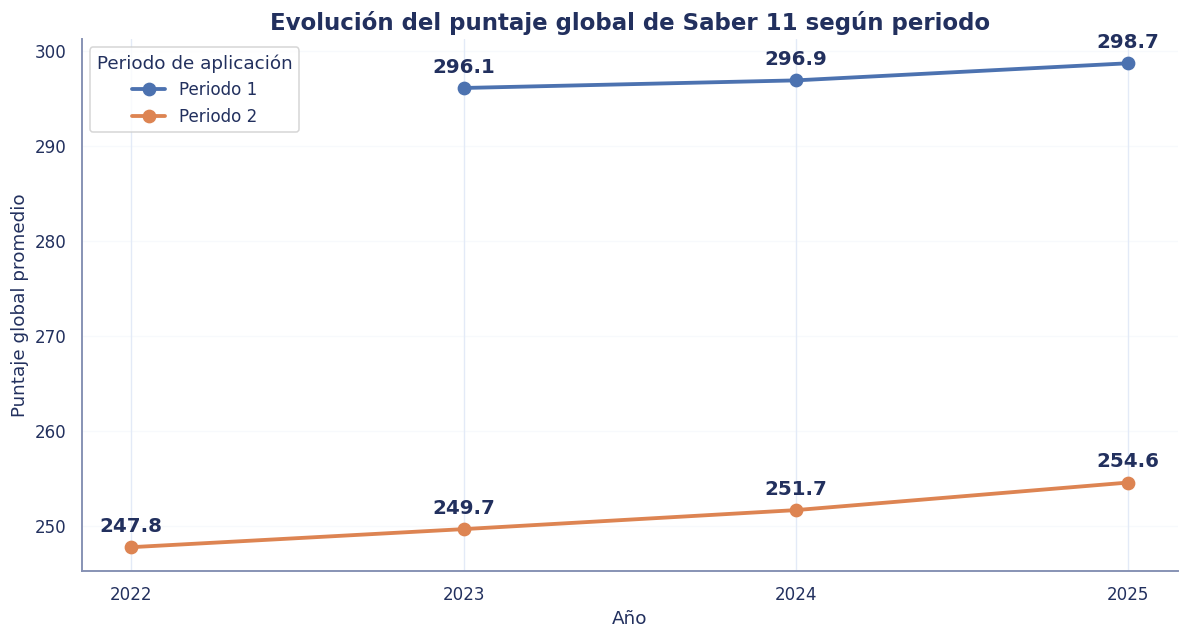

In [13]:
# Se crea el año y número de periodo

df_grafica = df.copy()

df_grafica["anio"] = df_grafica["Año"].astype(int)
df_grafica["periodo"] = df_grafica["periodo"].astype(str).str[4:].astype(int)

# Calculo de promedio y cantidad por año y periodo

resumen = (
    df_grafica
    .groupby(["anio", "periodo"])["punt_global"]
    .agg(
        cantidad="count",
        promedio="mean"
    )
    .reset_index()
)

resumen["promedio"] = resumen["promedio"].round(1)

display(resumen)

# Gráfica


fig, ax = plt.subplots(figsize=(11, 6))

for periodo in [1, 2]:

    datos = resumen[
        resumen["periodo"] == periodo
    ].sort_values("anio")

    ax.plot(
        datos["anio"],
        datos["promedio"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        label=f"Periodo {periodo}"
    )

    # Mostrar el promedio encima de cada punto
    for _, fila in datos.iterrows():

        ax.annotate(
            f'{fila["promedio"]:.1f}',
            (fila["anio"], fila["promedio"]),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontweight="bold"
        )


ax.set_title(
    "Evolución del puntaje global de Saber 11 según periodo",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Año")
ax.set_ylabel("Puntaje global promedio")

ax.set_xticks(
    sorted(resumen["anio"].unique())
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    title="Periodo de aplicación"
)

plt.tight_layout()
plt.show()

In [14]:
tabla_periodos = resumen.pivot(
  index="anio",
  columns="periodo",
  values="promedio"
)

tabla_periodos.columns = [
    f"periodo_{col}"
    for col in tabla_periodos.columns
]

# Solo habrá brecha cuando existan ambos periodos
tabla_periodos["brecha"] = (
    tabla_periodos["periodo_1"]
    - tabla_periodos["periodo_2"]
)

display(tabla_periodos.round(1))

,periodo_1,periodo_2,brecha
anio,,,
2022,NaN,247.8,NaN
2023,296.1,249.7,46.4
2024,296.9,251.7,45.2
2025,298.7,254.6,44.1


En ambos periodos se observa un incremento progresivo del puntaje global promedio a través de los años. El periodo 1 mantiene los mayores puntajes, pasando de 296,1 puntos en 2023 a 298,7 en 2025. Por su parte, el periodo 2 aumenta de 247,8 puntos en 2022 a 254,6 en 2025. Aunque el periodo 2 mantiene resultados considerablemente inferiores, presenta un crecimiento mayor durante el periodo analizado.

Además, la brecha entre ambos periodos disminuye ligeramente: pasa de aproximadamente 46,4 puntos en 2023 a 44,1 en 2025. Esto sugiere una reducción moderada de la brecha entre los grupos, aunque esta continúa siendo considerablemente grande.

## Relacion entre el estrato socioeconomico, la situacion economica de la familia y el puntaje global del ICFES

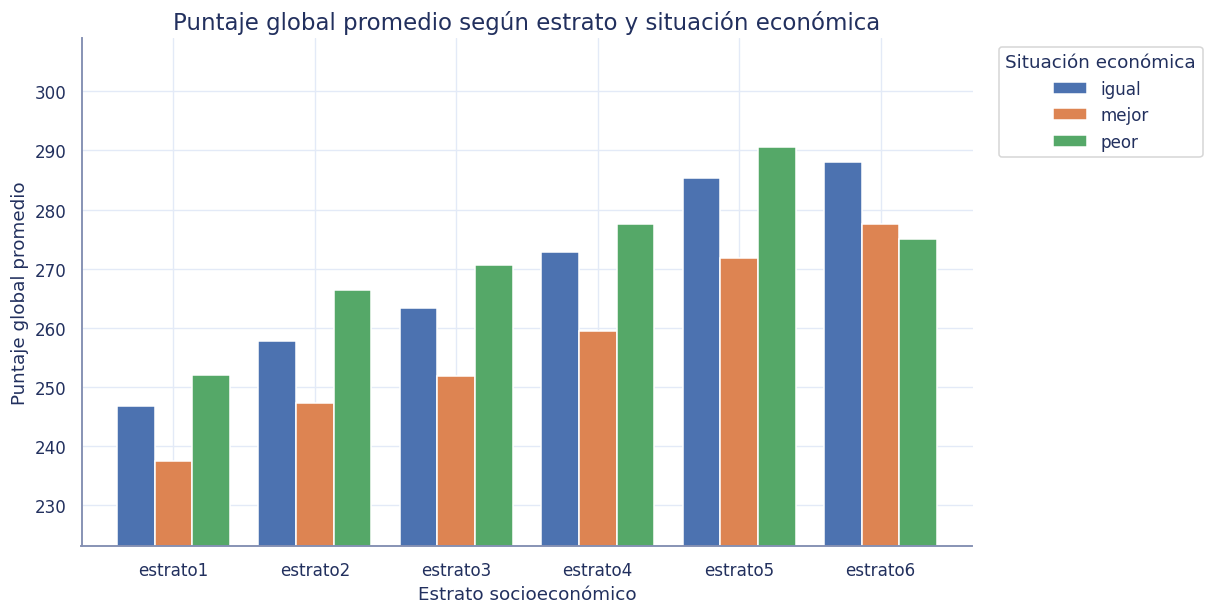

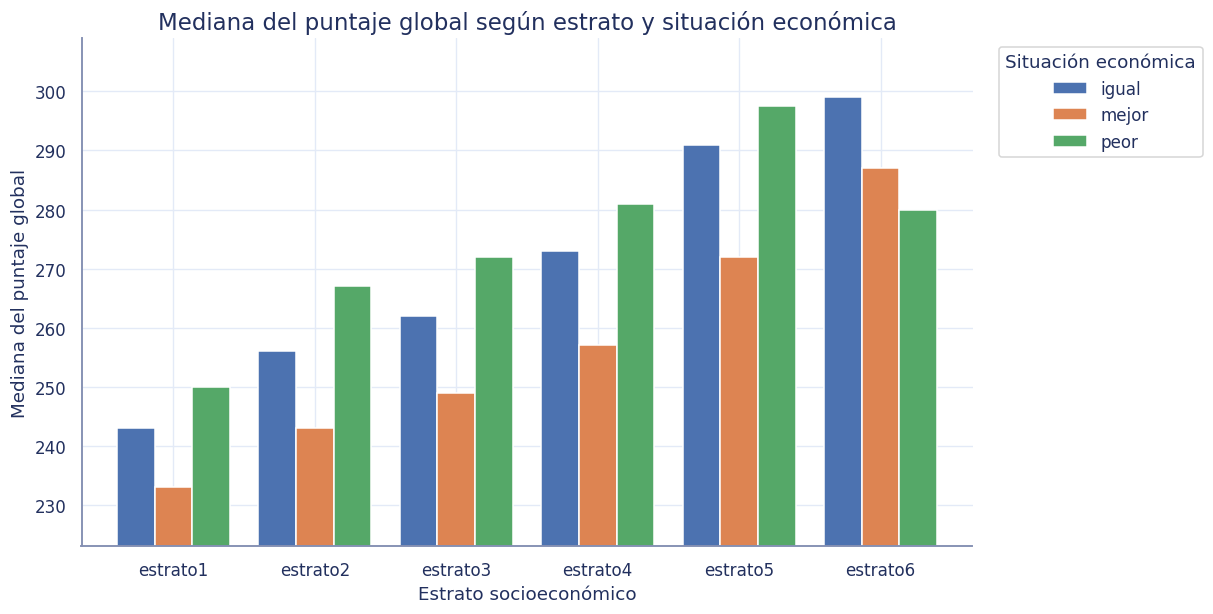

In [15]:
import matplotlib.pyplot as plt

# Orden de las categorías
orden_estrato = [
    "estrato1",
    "estrato2",
    "estrato3",
    "estrato4",
    "estrato5",
    "estrato6"
]

orden_situacion = [
    "igual",
    "mejor",
    "peor"
]


tabla_media = df.pivot_table(
    values="punt_global",
    index="fami_estratovivienda",
    columns="fami_situacioneconomica",
    aggfunc="mean"
)

tabla_media = (
    tabla_media
    .reindex(orden_estrato)
    .reindex(columns=orden_situacion)
)


tabla_mediana = df.pivot_table(
    values="punt_global",
    index="fami_estratovivienda",
    columns="fami_situacioneconomica",
    aggfunc="median"
)

tabla_mediana = (
    tabla_mediana
    .reindex(orden_estrato)
    .reindex(columns=orden_situacion)
)


minimo = min(
    tabla_media.min().min(),
    tabla_mediana.min().min()
)

maximo = max(
    tabla_media.max().max(),
    tabla_mediana.max().max()
)

# Margen visual
limite_inferior = minimo - 10
limite_superior = maximo + 10

#Grafica de la media
ax = tabla_media.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_title(
    "Puntaje global promedio según estrato y situación económica",
    fontsize=15
)

ax.set_xlabel(
    "Estrato socioeconómico",
    fontsize=12
)

ax.set_ylabel(
    "Puntaje global promedio",
    fontsize=12
)

ax.set_ylim(
    limite_inferior,
    limite_superior
)

plt.xticks(
    rotation=0
)

ax.legend(
    title="Situación económica",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.subplots_adjust(
    right=0.80
)

plt.show()

#Grafica de la mediana
ax = tabla_mediana.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_title(
    "Mediana del puntaje global según estrato y situación económica",
    fontsize=15
)

ax.set_xlabel(
    "Estrato socioeconómico",
    fontsize=12
)

ax.set_ylabel(
    "Mediana del puntaje global",
    fontsize=12
)

ax.set_ylim(
    limite_inferior,
    limite_superior
)

plt.xticks(
    rotation=0
)

ax.legend(
    title="Situación económica",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.subplots_adjust(
    right=0.80
)

plt.show()

Al comparar los resultados obtenidos mediante la media y la mediana, se observa un patrón similar entre ambas medidas de tendencia central. Esto sugiere que las diferencias observadas entre los grupos no parecen estar explicadas principalmente por valores extremos.

En los estratos 1 a 5, los estudiantes que reportan que la situación económica de su hogar se encuentra peor que el año anterior presentan, en promedio, los puntajes globales más altos dentro de su respectivo estrato, seguidos generalmente por quienes indican que la situación permanece igual y posteriormente por quienes indican que ha mejorado. Sin embargo, esta tendencia cambia en el estrato 6, donde los estudiantes que reportan una situación económica igual presentan el mayor promedio.

Adicionalmente, se evidencia una relación positiva entre el estrato socioeconómico y el desempeño académico. En términos generales, a medida que aumenta el estrato también aumenta el puntaje global, patrón que se mantiene para las distintas categorías de percepción económica, aunque con algunas variaciones en los estratos superiores.

## Número de objetos, capital del hogar e interacciones familiares

(ES INTERESANTE) Se construye un índice simple de bienes (cantidad de respuestas si) para evaluar una relación tipo dosis-respuesta. También se cruzan libros y educación parental con el puntaje por área, conservando conteos para distinguir patrones sólidos de celdas pequeñas.

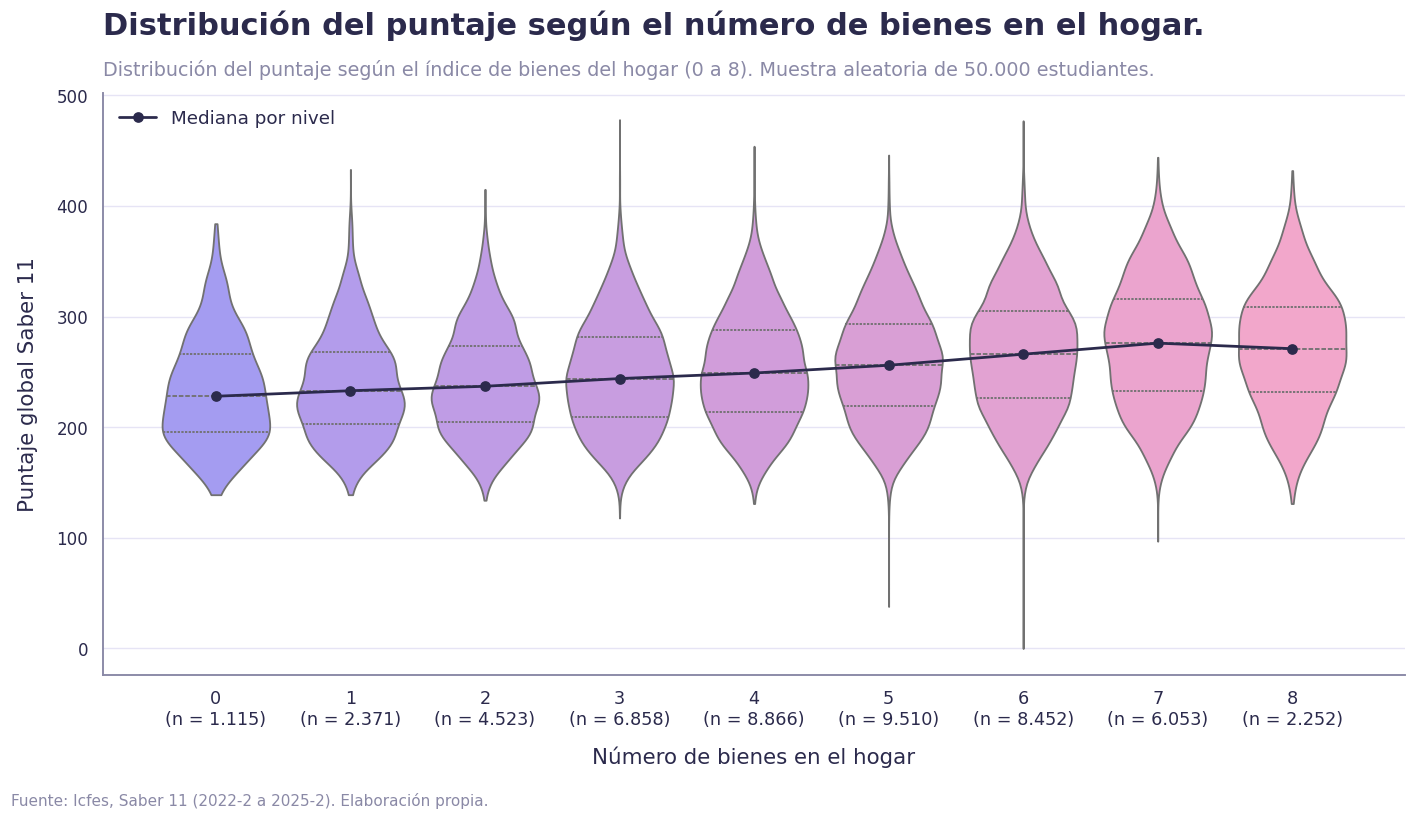

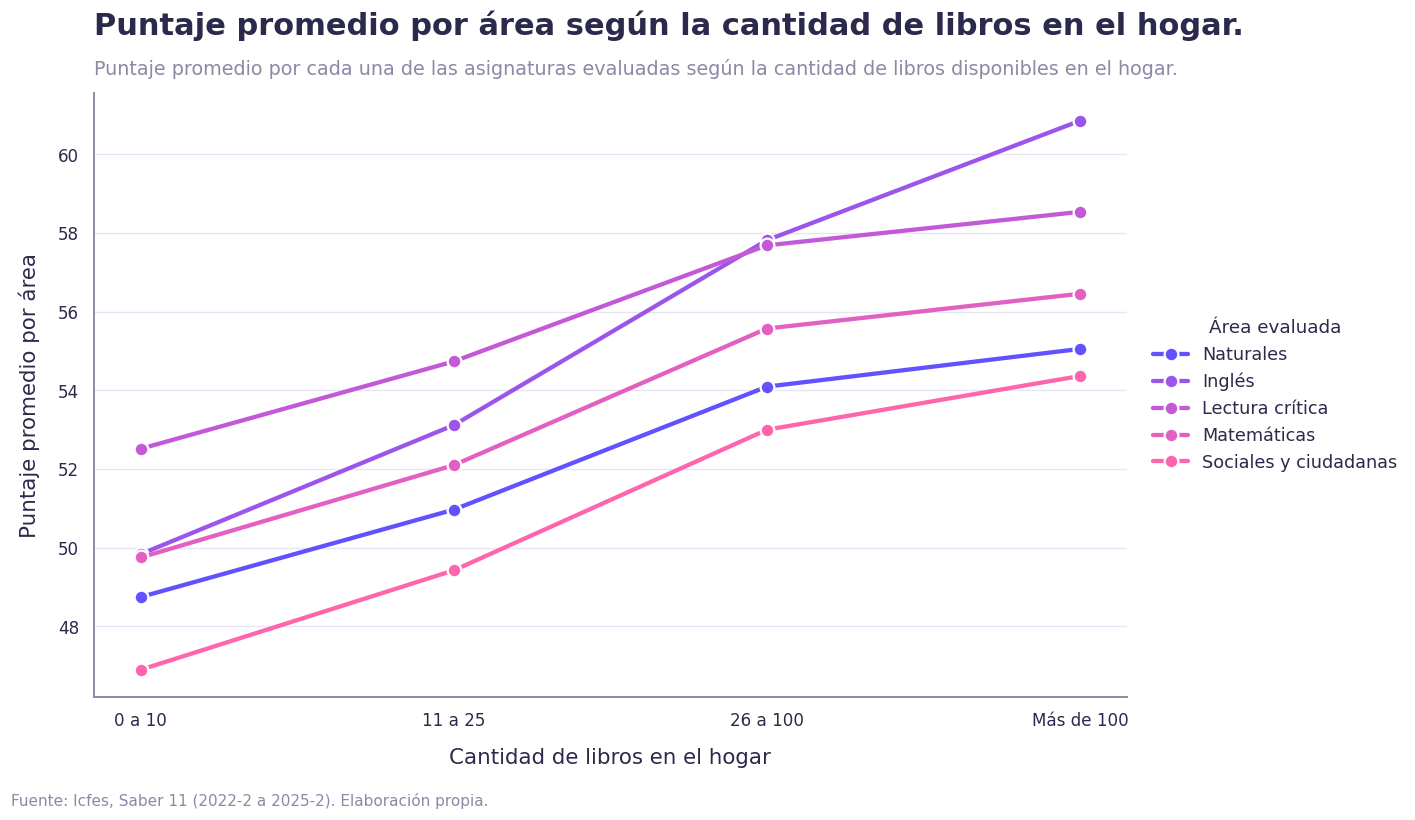

Mediana y tamaño por índice de bienes:
                   n  mediana  promedio
indice_bienes                          
0               3807    230.0    235.86
1               8228    232.0    237.38
2              15380    237.0    240.90
3              23118    243.0    246.87
4              29764    249.0    251.59
5              32094    257.0    257.61
6              28589    266.0    266.66
7              20149    276.0    276.17
8               7875    272.0    271.24


In [16]:
bienes_hogar = {
    "fami_tieneautomovil": "Automóvil",
    "fami_tienecomputador": "Computador",
    "fami_tieneconsolavideojuegos": "Consola de videojuegos",
    "fami_tienehornomicroogas": "Horno o microondas",
    "fami_tieneinternet": "Internet",
    "fami_tienelavadora": "Lavadora",
    "fami_tienemotocicleta": "Motocicleta",
    "fami_tieneserviciotv": "Servicio de televisión",
}

nombres_area = {
    "punt_c_naturales": "Naturales",
    "punt_ingles": "Inglés",
    "punt_lectura_critica": "Lectura crítica",
    "punt_matematicas": "Matemáticas",
    "punt_sociales_ciudadanas": "Sociales y ciudadanas",
}

PALETA = ["#6251ff", "#7d52f7", "#9254ef", "#a455e6", "#b457de", "#c359d6",
          "#d05bce", "#dd5dc6", "#e960be", "#f462b5", "#ff65ad"]
TEXTO = "#2b2a4c"
GRIS = "#8a89a6"
REJILLA = "#e6e4f5"

fuente = "Fuente: Icfes, Saber 11 (2022-2 a 2025-2). Elaboración propia."

cmap_ponencia = LinearSegmentedColormap.from_list("ponencia", PALETA)

def colores(n, suavizar=0.0):
    """n colores equidistantes de la gama. 'suavizar' (0 a 1) los mezcla con blanco -> tono pastel."""
    lista = []
    for x in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_ponencia(x)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TEXTO,
    "axes.labelcolor": TEXTO,
    "axes.edgecolor": GRIS,
    "xtick.color": TEXTO,
    "ytick.color": TEXTO,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": REJILLA,
    "grid.linewidth": 0.9,
})

def titulo(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRIS)

def miles(v):
    return f"{v:,}".replace(",", ".")


# 2. Figura 1: bienes del hogar vs. puntaje global
objetivo = 'punt_global' # Define 'objetivo' here
areas = list(nombres_area.keys()) # Define 'areas' here, assuming it should be the keys from nombres_area
bienes_disponibles = [variable for variable in bienes_hogar if variable in df.columns]
df["indice_bienes"] = df[bienes_disponibles].eq("si").sum(axis=1)

datos_bienes = df[["indice_bienes", objetivo]].dropna()
muestra_bienes = datos_bienes.sample(min(50000, len(datos_bienes)), random_state=42)

n_por_nivel = muestra_bienes["indice_bienes"].value_counts().sort_index()
niveles = list(n_por_nivel.index)
paleta_bienes = dict(zip(niveles, colores(len(niveles), suavizar=0.35)))
medianas = muestra_bienes.groupby("indice_bienes")[objetivo].median().reindex(niveles)

fig1, ax1 = plt.subplots(figsize=(13, 7.5))
sns.violinplot(
    data=muestra_bienes, x="indice_bienes", y=objetivo,
    hue="indice_bienes", order=niveles, hue_order=niveles,
    palette=paleta_bienes, inner="quartile", cut=0, linewidth=1.2,
    legend=False, ax=ax1,
)
ax1.plot(range(len(niveles)), medianas.values, color=TEXTO, marker="o",
         markersize=6, linewidth=1.8, zorder=5, label="Mediana por nivel")

ax1.set_xticks(range(len(niveles)))
ax1.set_xticklabels([f"{k}\n(n = {miles(n_por_nivel[k])})" for k in niveles], fontsize=11.5)
ax1.set_xlabel("Número de bienes en el hogar", fontsize=14, labelpad=12)
ax1.set_ylabel("Puntaje global Saber 11", fontsize=14, labelpad=12)
ax1.grid(axis="x", visible=False)
ax1.legend(frameon=False, loc="upper left", fontsize=12)

titulo(ax1,
       "Distribución del puntaje según el número de bienes en el hogar.",
       f"Distribución del puntaje según el índice de bienes del hogar (0 a {len(bienes_disponibles)}). "
       f"Muestra aleatoria de {miles(len(muestra_bienes))} estudiantes.")
fig1.text(0.01, 0.01, fuente, fontsize=10, color=GRIS)
fig1.tight_layout(rect=[0, 0.03, 1, 1])
# fig1.savefig("fig1_bienes_puntaje.png", dpi=300, bbox_inches="tight")
plt.show()


# 3. Figura 2: libros en el hogar vs. promedio por área

etiquetas_libros = {
    "0a10libros": "0 a 10",
    "11a25libros": "11 a 25",
    "26a100libros": "26 a 100",
    "masde100libros": "Más de 100",
}
orden_libros = [c for c in etiquetas_libros if c in df["fami_numlibros"].dropna().unique()]

libros_area = (
    df.groupby("fami_numlibros")[areas].mean()
      .rename(columns=nombres_area)
      .reindex(orden_libros)
)
libros_area.index = [etiquetas_libros[c] for c in libros_area.index]

fig2, ax2 = plt.subplots(figsize=(13, 7.5))
for columna, color in zip(libros_area.columns, colores(len(libros_area.columns))):
    ax2.plot(libros_area.index, libros_area[columna], color=color, marker="o",
             markersize=9, linewidth=2.8, markeredgecolor="white",
             markeredgewidth=1.5, label=columna)

ax2.set_xlabel("Cantidad de libros en el hogar", fontsize=14, labelpad=12)
ax2.set_ylabel("Puntaje promedio por área", fontsize=14, labelpad=12)
ax2.grid(axis="x", visible=False)
ax2.legend(title="Área evaluada", title_fontsize=12, fontsize=11.5, frameon=False,
           loc="center left", bbox_to_anchor=(1.01, 0.5))

titulo(ax2, "Puntaje promedio por área según la cantidad de libros en el hogar.",
       "Puntaje promedio por cada una de las asignaturas evaluadas según la cantidad de libros disponibles en el hogar.")
fig2.text(0.01, 0.01, fuente, fontsize=10, color=GRIS)
fig2.tight_layout(rect=[0, 0.03, 1, 1])
# fig2.savefig("fig2_libros_areas.png", dpi=300, bbox_inches="tight")
plt.show()


# 4. Tabla de apoyo
print("Mediana y tamaño por índice de bienes:")
print(df.groupby("indice_bienes")[objetivo].agg(n="size", mediana="median", promedio="mean").round(2))

En el grafico de violin se puede ver como la cantidad de objetos que tienen en el hogar se asocia con el puntaje global de los estudiantes donde la mediana aumenta progresivamente mientras aumenta el numero de bienes pero este muestra una tendencia creciente a partir de ninguno hasta el septimo objeto despues se ve ligera disminución, lo que podría sugerir una estabilización de la relación en los niveles de mas bienes. Sin embargo, existe un importante solapamiento entre las distribuciones, indicando que la disponibilidad de bienes no explica por sí sola el desempeño académico, esto quiere decir que aunque el puntaje típico aumenta cuando aumenta el número de bienes, sigue habiendo estudiantes con pocos bienes que obtienen puntajes altos y estudiantes con muchos bienes que obtienen puntajes bajos.

---

En el segundo grafico se puede ver la influencia de la cantidad de libros en el hogar con el puntaje en las diferentes areas A medida que aumenta el número de libros, también aumentan los puntajes promedio en las cinco diferentes asignaturas, esta asociacion se ve particularmente marcada en la asignatura de ingles que el promedio crece drasticamente a medida que crece la cantidad de libros. Este patrón sugiere que la disponibilidad de libros puede estar funcionando como un indicador de acceso a recursos educativos, hábitos culturales y condiciones socioeconómicas favorables que se asocian con el desempeño.

## Estrato socioeconomico, cantidad de libros y habitos de lectura

Se realiza con el fin de encontrar si hay una relacion entre el poder adquisitivo de las familias con la cantidad de libros que tienen disponibles en el hogar y como esto influye en los habitos de lectura y posteriormente en el desempeño global de las pruebas ICFES.

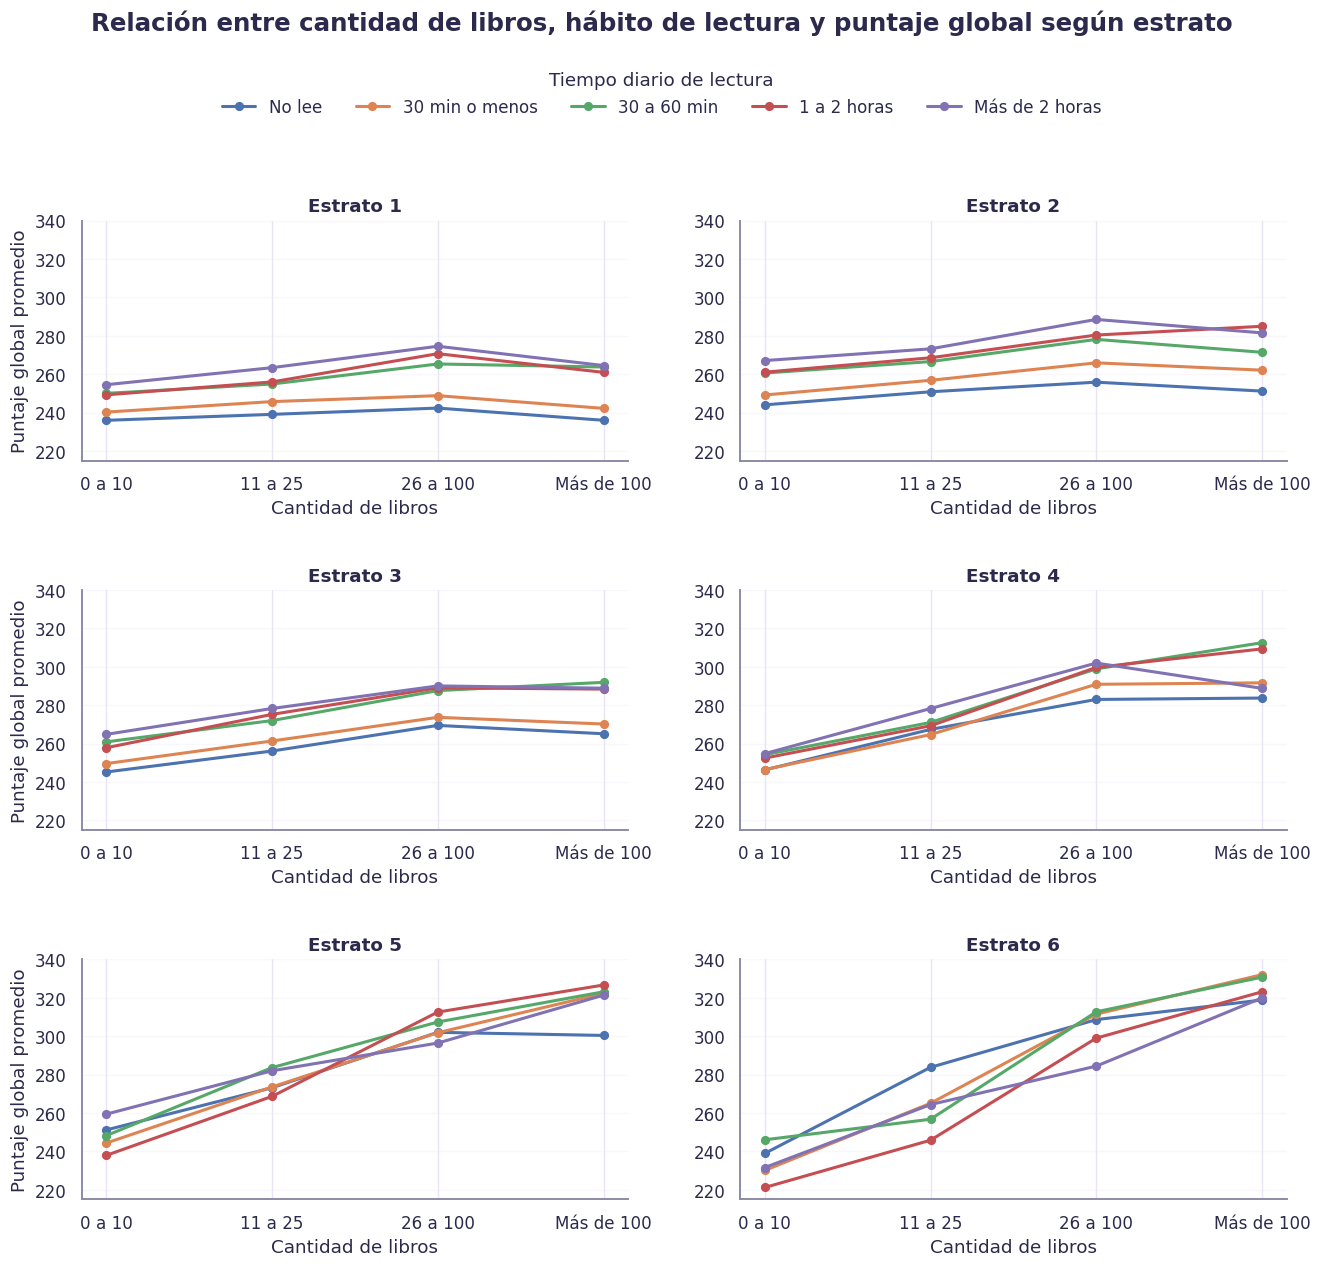

In [17]:
#Ordenar las categorias
orden_libros = [
    "0a10libros",
    "11a25libros",
    "26a100libros",
    "masde100libros"
]

orden_lectura = [
    "noleoporentretenimiento",
    "30minutosomenos",
    "entre30y60minutos",
    "entre1y2horas",
    "masde2horas"
]

orden_estrato = [
    "estrato1",
    "estrato2",
    "estrato3",
    "estrato4",
    "estrato5",
    "estrato6"
]

etiquetas_libros = [
    "0 a 10",
    "11 a 25",
    "26 a 100",
    "Más de 100"
]

etiquetas_lectura = {
    "noleoporentretenimiento": "No lee",
    "30minutosomenos": "30 min o menos",
    "entre30y60minutos": "30 a 60 min",
    "entre1y2horas": "1 a 2 horas",
    "masde2horas": "Más de 2 horas"
}

#Figuras

fig, axes = plt.subplots(
    3,
    2,
    figsize=(13, 12),

    # Compartimos solamente Y
    sharey=False,

    # IMPORTANTE:
    # No compartir X para que aparezcan las etiquetas
    sharex=False
)

axes = axes.flatten() # Move flatten call here
for ax in axes:
    ax.set_ylim(215, 340)


for i, (ax, estrato) in enumerate(
    zip(axes, orden_estrato)
):

    # Filtrar estrato
    datos = df[
        df["fami_estratovivienda"] == estrato
    ]

    # Crear tabla
    tabla = datos.pivot_table(
        values="punt_global",
        index="fami_numlibros",
        columns="estu_dedicacionlecturadiaria",
        aggfunc="mean",
        observed=True
    )

    # Ordenar categorías
    tabla = (
        tabla
        .reindex(orden_libros)
        .reindex(columns=orden_lectura)
    )

    tabla = tabla.rename(
        columns=etiquetas_lectura
    )

    tabla.plot(
        ax=ax,
        marker="o",
        linewidth=2,
        markersize=5,
        legend=False
    )


    ax.set_title(
        estrato.replace("estrato", "Estrato "),
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xticks(
        range(len(orden_libros))
    )

    ax.set_xticklabels(
        etiquetas_libros,
        rotation=0
    )

    ax.set_xlabel(
        "Cantidad de libros"
    )

    if i % 2 == 0:

        ax.set_ylabel(
            "Puntaje global promedio"
        )

    else:

        ax.set_ylabel("")


    ax.grid(
        axis="y",
        alpha=0.25
    )

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Tiempo diario de lectura",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=5,
    frameon=False
)

fig.suptitle(
    "Relación entre cantidad de libros, hábito de lectura y "
    "puntaje global según estrato",
    fontsize=16,
    fontweight="bold",
    y=0.99
)


plt.tight_layout(
    rect=[0.03, 0.03, 0.97, 0.90],
    h_pad=2.5,
    w_pad=2
)

plt.show()

El análisis conjunto del estrato socioeconómico, la cantidad de libros disponibles en el hogar y los hábitos de lectura evidencia una asociación entre estas características y el desempeño en Saber 11. En términos generales, los puntajes aumentan conforme aumenta el estrato socioeconómico y la cantidad de libros disponibles. En los estratos 1 a 3 se observa que el incremento asociado con los libros tiende a estabilizarse alrededor de los 26 a 100 libros, mientras que en los estratos superiores la relación creciente se mantiene con mayor frecuencia hasta la categoría de más de 100 libros.

Asimismo, los estudiantes que reportan hábitos de lectura suelen presentar mejores resultados que quienes no leen por entretenimiento. Sin embargo, la relación entre tiempo de lectura y puntaje no es completamente lineal, ya que las categorías de mayor dedicación presentan cruces y variaciones dependiendo del estrato y de la cantidad de libros. Esto sugiere una posible interacción entre las condiciones socioeconómicas, la disponibilidad de recursos educativos y los hábitos de lectura.

## Matemáticas y Lectura crítica según el colegio y el territorio

Cada figura se presenta por separado para facilitar la lectura. Las cajas y violines comparan la distribución completa de Matemáticas y Ciencias naturales, no solamente el promedio. Para municipios se muestran las categorías con mayor cantidad de estudiantes y se conserva el tamaño muestral.

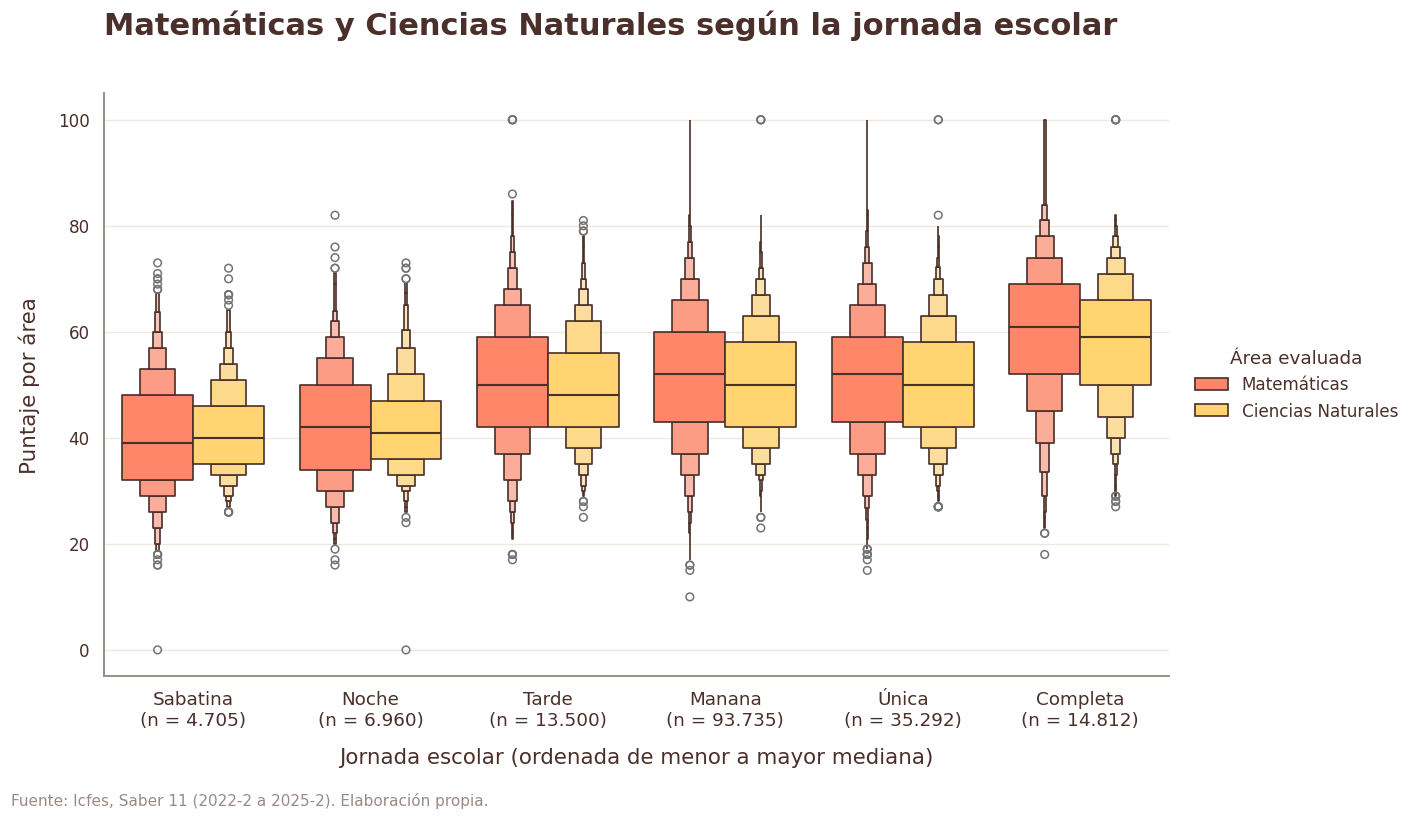

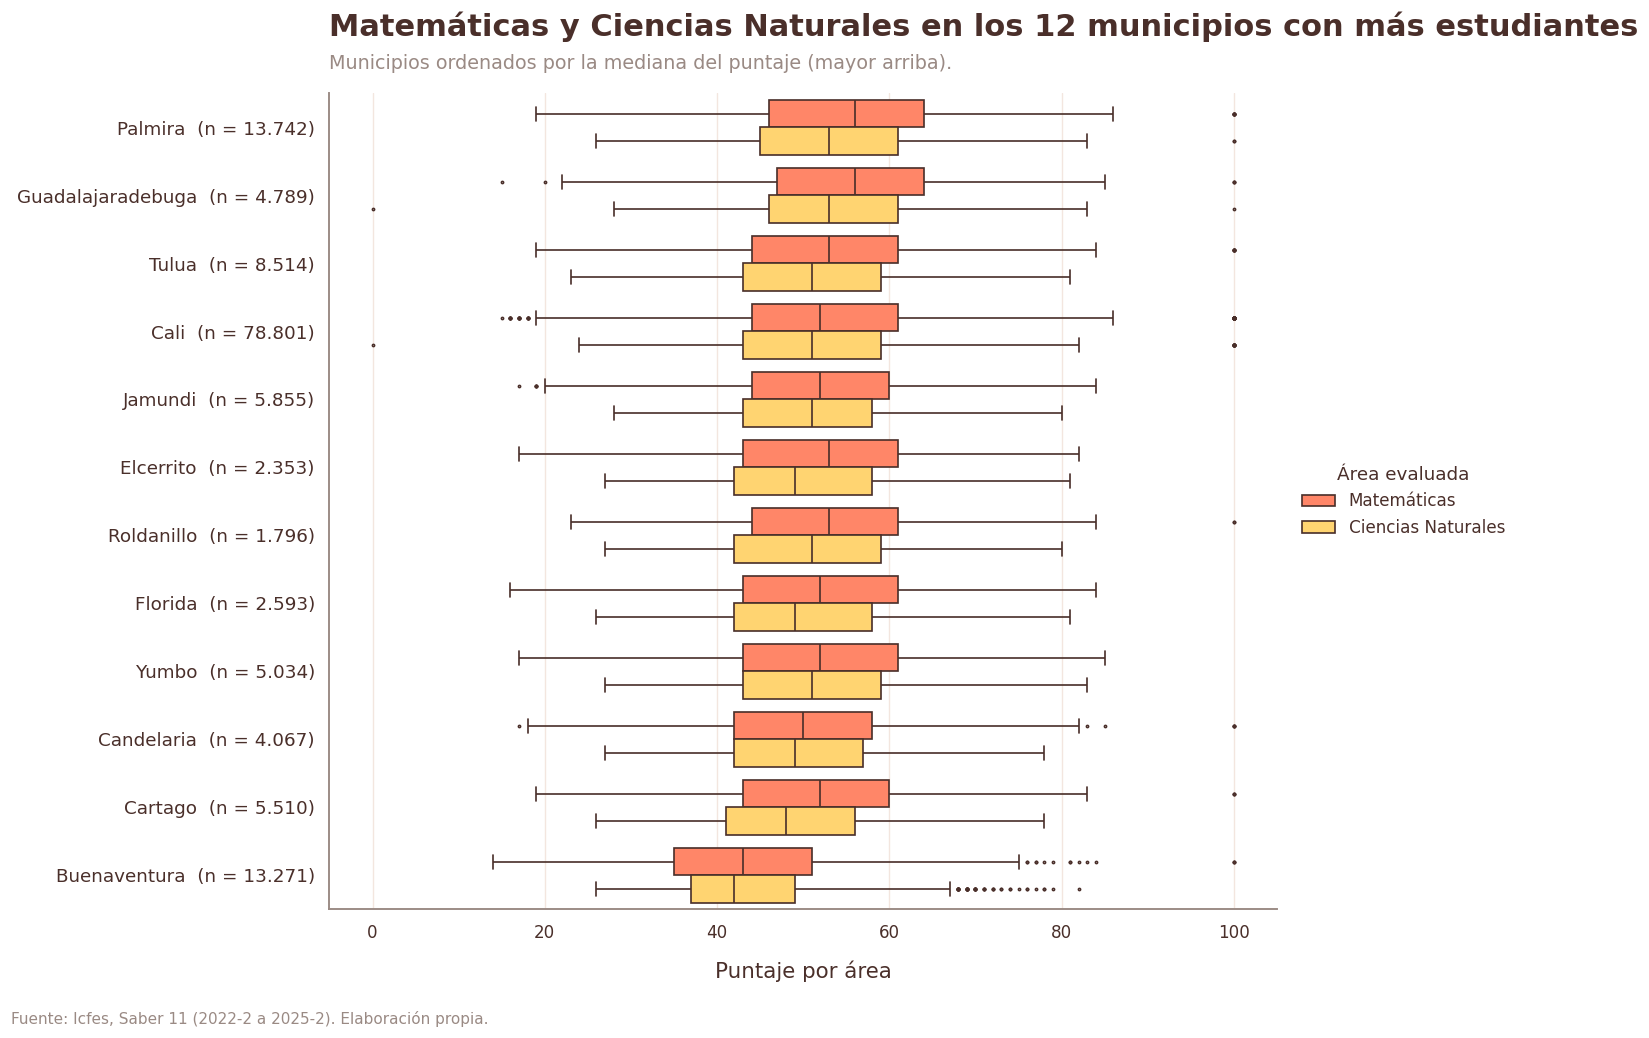

In [18]:
PALETA_CALIDA = ["#ff5e36", "#ff713c", "#ff8241", "#ff9247", "#ffa24e", "#ffb154",
                 "#ffc05a", "#ffcf61", "#ffdd67", "#ffec6e", "#fffa75"]
TXT = "#4a2f2a"    # marrón oscuro cálido: títulos, ejes y contornos
GRS = "#9a8a84"    # subtítulos y notas
GRD = "#f3e6df"    # rejilla suave

fuente = "Fuente: Icfes, Saber 11 (2022-2 a 2025-2). Elaboración propia."

def aclarar(hex_color, f=0.0):
    """Mezcla el color con blanco (f entre 0 y 1) para lograr un tono pastel."""
    rgb = np.array(to_rgb(hex_color))
    return tuple(rgb + (1 - rgb) * f)

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT,
    "axes.labelcolor": TXT,
    "axes.edgecolor": GRS,
    "xtick.color": TXT,
    "ytick.color": TXT,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD,
    "grid.linewidth": 0.9,
})

def titulo_c(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS)

areas_colegio = {
    "punt_matematicas": "Matemáticas",
    "punt_c_naturales": "Ciencias Naturales",
}
orden_areas = list(areas_colegio.values())

colores_area = {
    "Matemáticas": aclarar(PALETA_CALIDA[0], 0.25),
    "Ciencias Naturales": aclarar(PALETA_CALIDA[7], 0.10),
}

def a_formato_largo(columna, filtro=None):
    """Devuelve (tabla larga Área/Puntaje, n de estudiantes por categoría) con etiquetas limpias."""
    base = df[[columna, *areas_colegio]].dropna(subset=[columna]).copy()
    if filtro is not None:
        base = base[base[columna].isin(filtro)]
    base[columna] = base[columna].astype(str).str.strip().str.title().replace({"Unica": "Única"})
    n_estudiantes = base[columna].value_counts()
    largo = base.melt(id_vars=columna, var_name="Área", value_name="Puntaje").dropna(subset=["Puntaje"])
    largo["Área"] = largo["Área"].map(areas_colegio)
    return largo, n_estudiantes

def etiquetas_con_n(orden, n_estudiantes, salto="\n"):
    return [f"{c}{salto}(n = {miles(n_estudiantes[c])})" for c in orden]

jornada, n_jornada = a_formato_largo("cole_jornada")
orden_jornada = jornada.groupby("cole_jornada")["Puntaje"].median().sort_values().index
muestra_jornada = jornada.sample(min(60000, len(jornada)), random_state=42)

fig_jor, ax = plt.subplots(figsize=(13, 7.5))
sns.boxenplot(data=muestra_jornada, x="cole_jornada", y="Puntaje", hue="Área",
              order=orden_jornada, hue_order=orden_areas, palette=colores_area,
              saturation=1, linewidth=1.1, linecolor=TXT, ax=ax)
ax.set_xticks(range(len(orden_jornada)))
ax.set_xticklabels(etiquetas_con_n(orden_jornada, n_jornada), fontsize=12)
ax.set_xlabel("Jornada escolar (ordenada de menor a mayor mediana)", fontsize=14, labelpad=12)
ax.set_ylabel("Puntaje por área", fontsize=14, labelpad=12)
ax.grid(axis="x", visible=False)
sns.move_legend(ax, "center left", bbox_to_anchor=(1.01, 0.5), title="Área evaluada", frameon=False)
titulo_c(ax, "Matemáticas y Ciencias Naturales según la jornada escolar", "")
fig_jor.text(0.01, 0.01, fuente, fontsize=10, color=GRS)
fig_jor.tight_layout(rect=[0, 0.03, 1, 1])

plt.show()


municipios_colegio = df["cole_mcpio_ubicacion"].value_counts().head(12).index
municipio_colegio, n_municipio = a_formato_largo("cole_mcpio_ubicacion", filtro=municipios_colegio)

orden_municipio = municipio_colegio.groupby("cole_mcpio_ubicacion")["Puntaje"].median().sort_values(ascending=False).index
muestra_municipio = municipio_colegio.sample(min(70000, len(municipio_colegio)), random_state=42)

fig_mun, ax = plt.subplots(figsize=(14, 9.5))
sns.boxplot(data=muestra_municipio, x="Puntaje", y="cole_mcpio_ubicacion", hue="Área",
            order=orden_municipio, hue_order=orden_areas, palette=colores_area,
            saturation=1, linewidth=1.1, linecolor=TXT, fliersize=1.5, ax=ax)
ax.set_yticks(range(len(orden_municipio)))
ax.set_yticklabels(etiquetas_con_n(orden_municipio, n_municipio, salto="  "), fontsize=12)
ax.set_xlabel("Puntaje por área", fontsize=14, labelpad=12)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
sns.move_legend(ax, "center left", bbox_to_anchor=(1.01, 0.5), title="Área evaluada", frameon=False)
titulo_c(ax, "Matemáticas y Ciencias Naturales en los 12 municipios con más estudiantes",
         "Municipios ordenados por la mediana del puntaje (mayor arriba). ")
fig_mun.text(0.01, 0.01, fuente, fontsize=10, color=GRS)
fig_mun.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


Según la literatura consultada el puntaje de matemáticas y ciencias naturales se relaciona de gran forma con el punaje saber. El análisis según jornada escolar evidencia diferencias consistentes en Matemáticas y Ciencias Naturales. Las jornadas sabatina y nocturna presentan las menores medianas, con valores cercanos a 40–41 puntos, mientras que las jornadas de mañana y única alcanzan aproximadamente 50–52 puntos. La jornada completa presenta los mejores resultados, con medianas de 62 puntos en Matemáticas y 60 en Ciencias Naturales. Ambas áreas muestran patrones muy similares y diferencias reducidas entre sí, lo que sugiere que la asociación observada está relacionada principalmente con la jornada y no exclusivamente con un área específica. No obstante, se puede ver solapamiento de las distribuciones lo que puede indicar una alta variabilidad de resultados dentro de cada jornada lo que sugiere que estudiantes por ejemplo de jornada sabatina pueden tener mejores resultados que estudiantes de jornada unica y viseversa.

---

Al comparar los municipios se observa una alta similitud en el comportamiento de Matemáticas y Ciencias Naturales. Palmira y Guadalajara de Buga presentan las mayores medianas, con aproximadamente 55 puntos en Matemáticas y 53 en Ciencias Naturales, seguidas por Tuluá y Cali. En contraste, Buenaventura presenta las menores medianas, con aproximadamente 43 y 42 puntos respectivamente. La diferencia de alrededor de 11–12 puntos entre los extremos evidencia una brecha territorial relevante en el desempeño.

A pesar de estas diferencias en las medidas centrales, las distribuciones presentan un solapamiento entre municipios, por lo que existe una amplia variedad de resultados dentro de cada territorio. Asimismo, Matemáticas mantiene generalmente medianas ligeramente superiores a Ciencias Naturales, aunque ambas áreas presentan patrones territoriales muy similares. Además cabe resaltar que Buenaventura presenta una cantidad visible de observaciones altas alejadas de su distribución central, a pesar de mantener las medianas más bajas dentro del grafico.

## Hábitos alimenticios con relacion a los puntajes

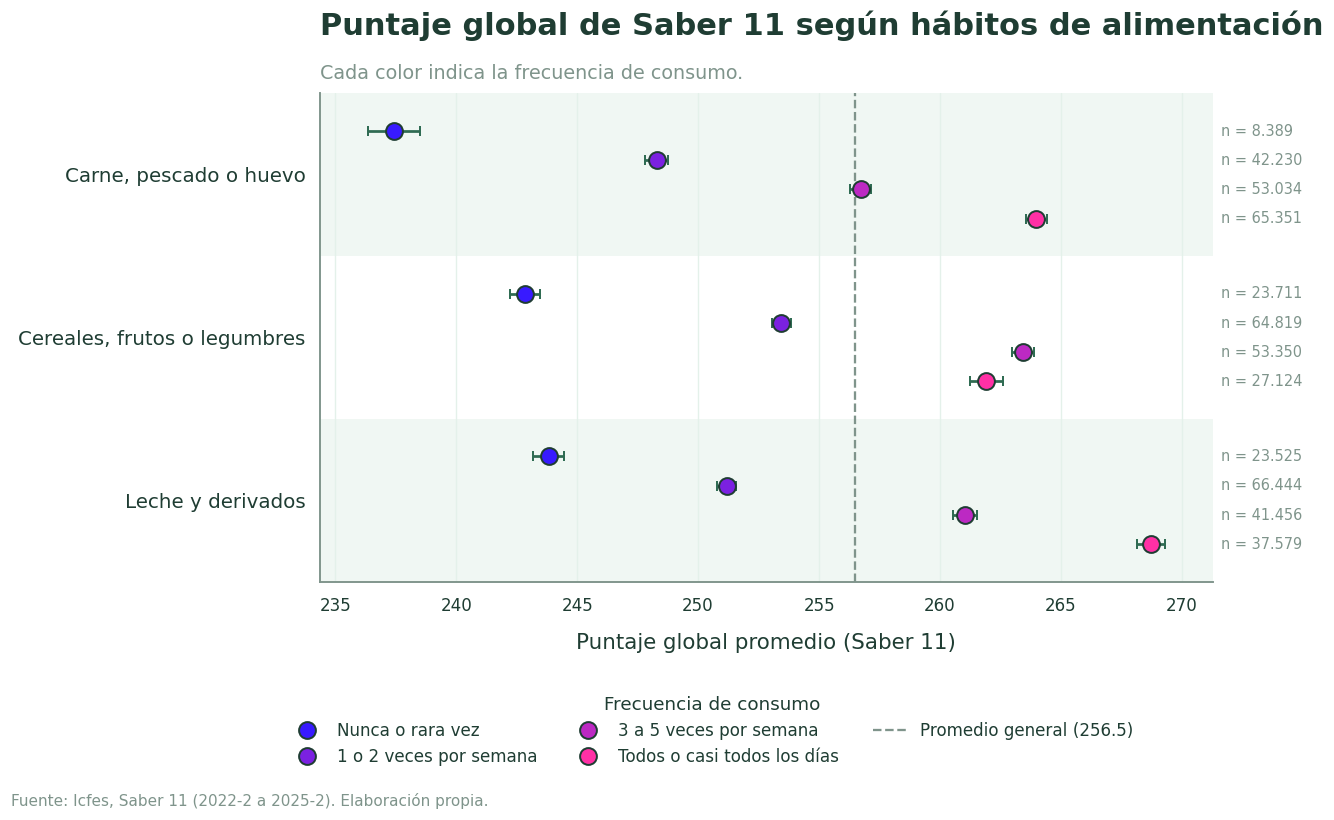

In [26]:
PALETA_VERDE = ["#2200ff", "#6c08de", "#b511bc", "#ff199b"]
TXT_V = "#1f3d33"     # verde muy oscuro: títulos, ejes y contornos
TRAZO_V = "#2f6b52"   # verde medio-oscuro: barras de error y líneas
GRS_V = "#7f948b"     # subtítulos y notas
GRD_V = "#e4f1ea"     # rejilla y franjas suaves

fuente = ("Fuente: Icfes, Saber 11 (2022-2 a 2025-2). Elaboración propia. ")

cmap_verde = LinearSegmentedColormap.from_list("verde", PALETA_VERDE)

def colores_verdes(n, suavizar=0.0):
    """n colores equidistantes de la gama; 'suavizar' los mezcla con blanco (tono pastel)."""
    lista = []
    for v in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_verde(v)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT_V,
    "axes.labelcolor": TXT_V,
    "axes.edgecolor": GRS_V,
    "xtick.color": TXT_V,
    "ytick.color": TXT_V,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD_V,
    "grid.linewidth": 0.9,
})

def titulo_v(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS_V)

#
# Agrupación de categorías y resumen estadístico
OBJETIVO = "punt_global"

# Alimentación: 4 niveles de frecuencia, comunes a los tres alimentos
niveles_consumo = ["Nunca o rara vez", "1 o 2 veces por semana",
                   "3 a 5 veces por semana", "Todos o casi todos los días"]
codigos_consumo = {
    "nuncaoraravezcomemoseso": niveles_consumo[0],
    "1o2vecesporsemana": niveles_consumo[1],
    "3a5vecesporsemana": niveles_consumo[2],
    "todosocasitodoslosdias": niveles_consumo[3],
}
variables_alimentacion = {
    "fami_comecarnepescadohuevo": "Carne, pescado o huevo",
    "fami_comecerealfrutoslegumbre": "Cereales, frutos o legumbres",
    "fami_comelechederivados": "Leche y derivados",
}

# Cuartos del hogar: 6+ categorías englobadas en 3 grupos (edita este diccionario si prefieres otro corte)
niveles_cuartos = ["1 a 2 cuartos", "3 a 4 cuartos", "5 o más cuartos"]
codigos_cuartos = {
    "uno": niveles_cuartos[0], "dos": niveles_cuartos[0],
    "tres": niveles_cuartos[1], "cuatro": niveles_cuartos[1],
    "cinco": niveles_cuartos[2], "seis": niveles_cuartos[2],
    "seisomas": niveles_cuartos[2], "masde6": niveles_cuartos[2],
}

def resumen_categoria(variable, mapa_categorias, orden_niveles):
    """n, promedio, desviación e IC 95 % del puntaje global por categoría (ya agrupada)."""
    datos = df[[variable, OBJETIVO]].dropna().copy()
    sin_mapa = sorted(set(datos[variable].unique()) - set(mapa_categorias))
    if sin_mapa:
        print(f"Aviso ({variable}): categorías sin agrupar, excluidas del gráfico -> {sin_mapa}")
    datos["categoria"] = datos[variable].map(mapa_categorias)
    resumen = (
        datos.dropna(subset=["categoria"])
        .groupby("categoria")[OBJETIVO]
        .agg(n="size", promedio="mean", desviacion="std")
    )
    resumen["ic95"] = 1.96 * resumen["desviacion"] / np.sqrt(resumen["n"])   # el 1.96 se aplica una sola vez
    return resumen.reindex([c for c in orden_niveles if c in resumen.index])

filas = []
for variable, nombre in variables_alimentacion.items():
    r = resumen_categoria(variable, codigos_consumo, niveles_consumo).reset_index()
    r.insert(0, "variable", nombre)
    filas.append(r)
resumen_alimentos = pd.concat(filas, ignore_index=True)
resumen_cuartos = resumen_categoria("fami_cuartoshogar", codigos_cuartos, niveles_cuartos)

promedio_general = df[OBJETIVO].mean()

# Figura hábitos alimenticios
nombres_filas = list(variables_alimentacion.values())
colores_consumo = dict(zip(niveles_consumo, colores_verdes(len(niveles_consumo), suavizar=0.10)))
desplazamiento = dict(zip(niveles_consumo, np.linspace(-0.27, 0.27, len(niveles_consumo))))

fig_alim, ax = plt.subplots(figsize=(13, 7.5))

for i in range(len(nombres_filas)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color=GRD_V, alpha=0.55, linewidth=0, zorder=0)

ax.axvline(promedio_general, color=GRS_V, linestyle="--", linewidth=1.5, zorder=1)

for _, fila in resumen_alimentos.iterrows():
    y_pos = nombres_filas.index(fila["variable"]) + desplazamiento[fila["categoria"]]
    ax.errorbar(fila["promedio"], y_pos, xerr=fila["ic95"], fmt="o",
                ecolor=TRAZO_V, elinewidth=1.8, capsize=3.5, markersize=11,
                markerfacecolor=colores_consumo[fila["categoria"]],
                markeredgecolor=TXT_V, markeredgewidth=1.3, zorder=4)
    ax.text(1.01, y_pos, f"n = {miles(fila['n'])}", transform=ax.get_yaxis_transform(),
            va="center", fontsize=9.5, color=GRS_V)

lim_inf = min((resumen_alimentos["promedio"] - resumen_alimentos["ic95"]).min(), promedio_general)
lim_sup = max((resumen_alimentos["promedio"] + resumen_alimentos["ic95"]).max(), promedio_general)
margen = (lim_sup - lim_inf) * 0.06
ax.set_xlim(lim_inf - margen, lim_sup + margen)
ax.set_ylim(len(nombres_filas) - 0.5, -0.5)   # el primer alimento queda arriba
ax.set_yticks(range(len(nombres_filas)))
ax.set_yticklabels(nombres_filas, fontsize=13)
ax.set_xlabel("Puntaje global promedio (Saber 11)", fontsize=14, labelpad=12)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)

titulo_v(ax, "Puntaje global de Saber 11 según hábitos de alimentación", "Cada color indica la frecuencia de consumo.")

manijas = [Line2D([0], [0], marker="o", linestyle="", markersize=11,
                  markerfacecolor=colores_consumo[nivel], markeredgecolor=TXT_V,
                  markeredgewidth=1.3, label=nivel) for nivel in niveles_consumo]
manijas.append(Line2D([0], [0], color=GRS_V, linestyle="--", linewidth=1.5,
                      label=f"Promedio general ({promedio_general:.1f})"))
fig_alim.legend(handles=manijas, loc="lower center", bbox_to_anchor=(0.5, 0.04), ncol=3,
                frameon=False, fontsize=11, title="Frecuencia de consumo", title_fontsize=12)
fig_alim.text(0.01, 0.01, fuente, fontsize=10, color=GRS_V)
fig_alim.tight_layout(rect=[0, 0.17, 0.93, 1])

plt.show()


Los habitos alimenticios de una persona también está ligado a la capacidad adquisitiva de la familia o del entorno del estudiante. Estos presentan una asociación clara con el desempeño global. En los tres grupos de alimentos analizados, los estudiantes que reportan una mayor frecuencia de consumo presentan, en términos generales, puntajes promedio superiores. Las diferencias son especialmente marcadas en carne, pescado o huevo y en leche y derivados. En cereales, frutos o legumbres también se observa una mejora importante entre las frecuencias bajas y altas, aunque el comportamiento se estabiliza en las categorías de mayor consumo.




## Numero de habitaciones y numero de personas en el hogar con relacion al puntaje

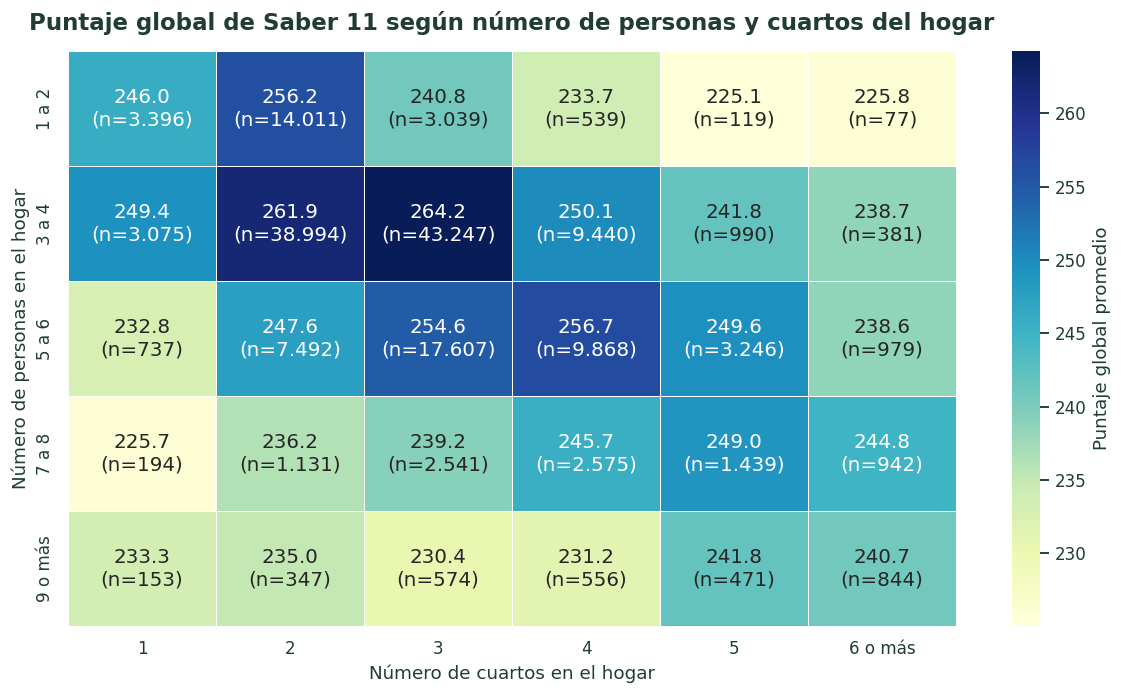

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orden_personas = [
    "1a2",
    "3a4",
    "5a6",
    "7a8",
    "9omas"
]

orden_cuartos = [
    "uno",
    "dos",
    "tres",
    "cuatro",
    "cinco",
    "seisomas"
]

etiquetas_personas = {
    "1a2": "1 a 2",
    "3a4": "3 a 4",
    "5a6": "5 a 6",
    "7a8": "7 a 8",
    "9omas": "9 o más"
}

etiquetas_cuartos = {
    "uno": "1",
    "dos": "2",
    "tres": "3",
    "cuatro": "4",
    "cinco": "5",
    "seisomas": "6 o más"
}


df_temp = df[
    ["fami_personashogar", "fami_cuartoshogar", "punt_global"]
].dropna().copy()

df_temp = df_temp[
    df_temp["fami_personashogar"].isin(orden_personas) &
    df_temp["fami_cuartoshogar"].isin(orden_cuartos)
]

tabla_prom = (
    df_temp.pivot_table(
        values="punt_global",
        index="fami_personashogar",
        columns="fami_cuartoshogar",
        aggfunc="mean",
        observed=True
    )
    .reindex(index=orden_personas, columns=orden_cuartos)
)

tabla_n = (
    df_temp.pivot_table(
        values="punt_global",
        index="fami_personashogar",
        columns="fami_cuartoshogar",
        aggfunc="count",
        observed=True
    )
    .reindex(index=orden_personas, columns=orden_cuartos)
)

anotaciones = tabla_prom.copy().astype(object)

for i in tabla_prom.index:
    for j in tabla_prom.columns:
        prom = tabla_prom.loc[i, j]
        n = tabla_n.loc[i, j]

        if pd.notna(prom) and pd.notna(n):
            anotaciones.loc[i, j] = f"{prom:.1f}\n(n={int(n):,})".replace(",", ".")
        else:
            anotaciones.loc[i, j] = ""


tabla_prom.index = [etiquetas_personas[x] for x in tabla_prom.index]
tabla_prom.columns = [etiquetas_cuartos[x] for x in tabla_prom.columns]

anotaciones.index = tabla_prom.index
anotaciones.columns = tabla_prom.columns


plt.figure(figsize=(11, 6.5))

ax = sns.heatmap(
    tabla_prom,
    annot=anotaciones,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Puntaje global promedio"}
)

ax.set_title(
    "Puntaje global de Saber 11 según número de personas y cuartos del hogar",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Número de cuartos en el hogar", fontsize=12)
ax.set_ylabel("Número de personas en el hogar", fontsize=12)

plt.tight_layout()
plt.show()

se observa que la relación depende del tamaño del hogar. En hogares de cinco o más integrantes, un mayor número de cuartos se asocia generalmente con mejores puntajes, mientras que los hogares muy numerosos presentan resultados inferiores en comparación con hogares de tres o cuatro personas.

Asimismo, la combinación asociada con los mayores puntajes se desplaza hacia un mayor número de cuartos conforme aumenta el número de integrantes del hogar, lo que sugiere que la disponibilidad de espacio por persona podría constituir un indicador más informativo que el número de cuartos considerado aisladamente. Las combinaciones con tamaños muestrales muy reducidos deben interpretarse con precaución. Por ejemplo, el bajo promedio observado en hogares de una o dos personas con seis o más cuartos se basa únicamente en 77 registros y no debería utilizarse para inferir una relación general.

## Hábitos del estudiante

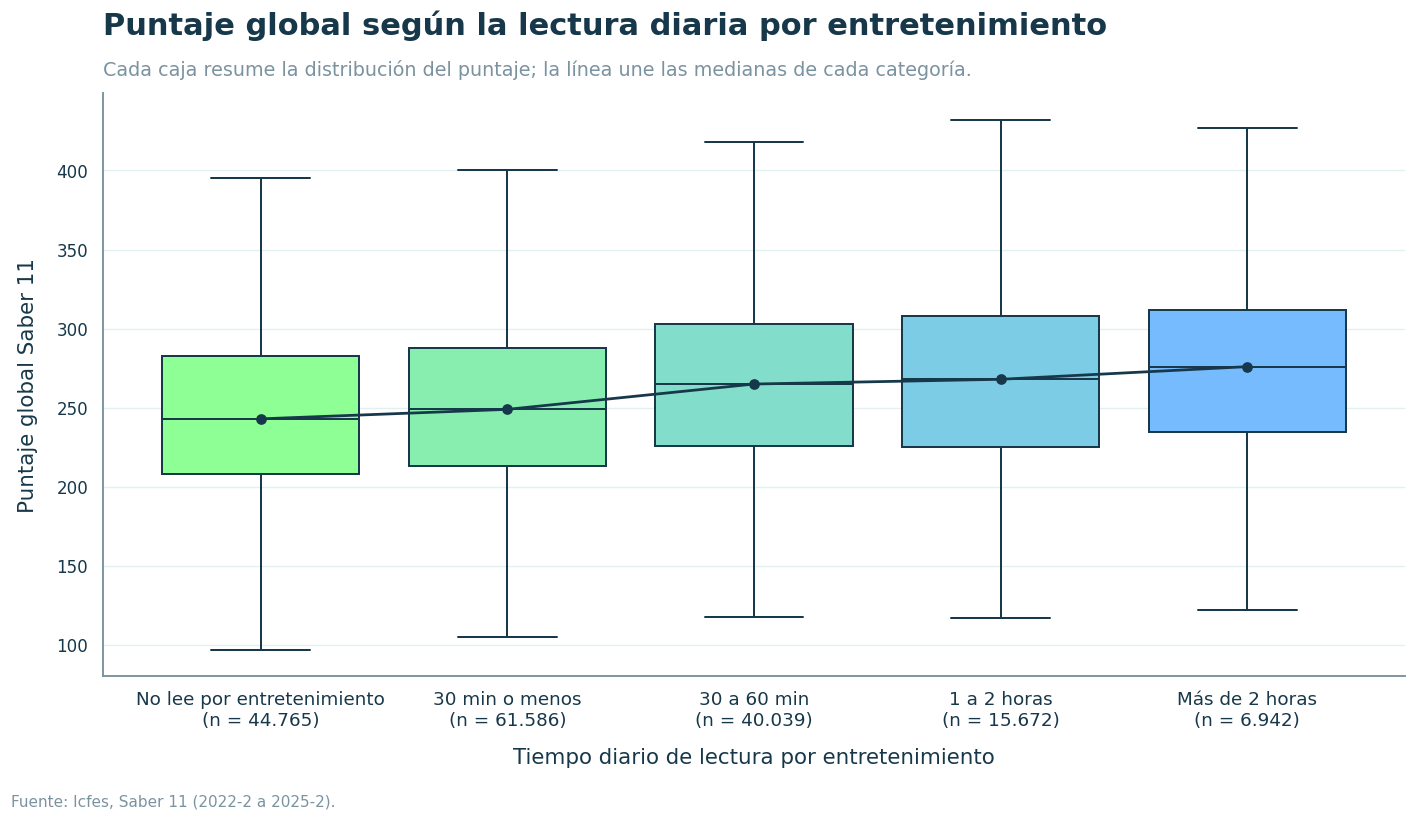

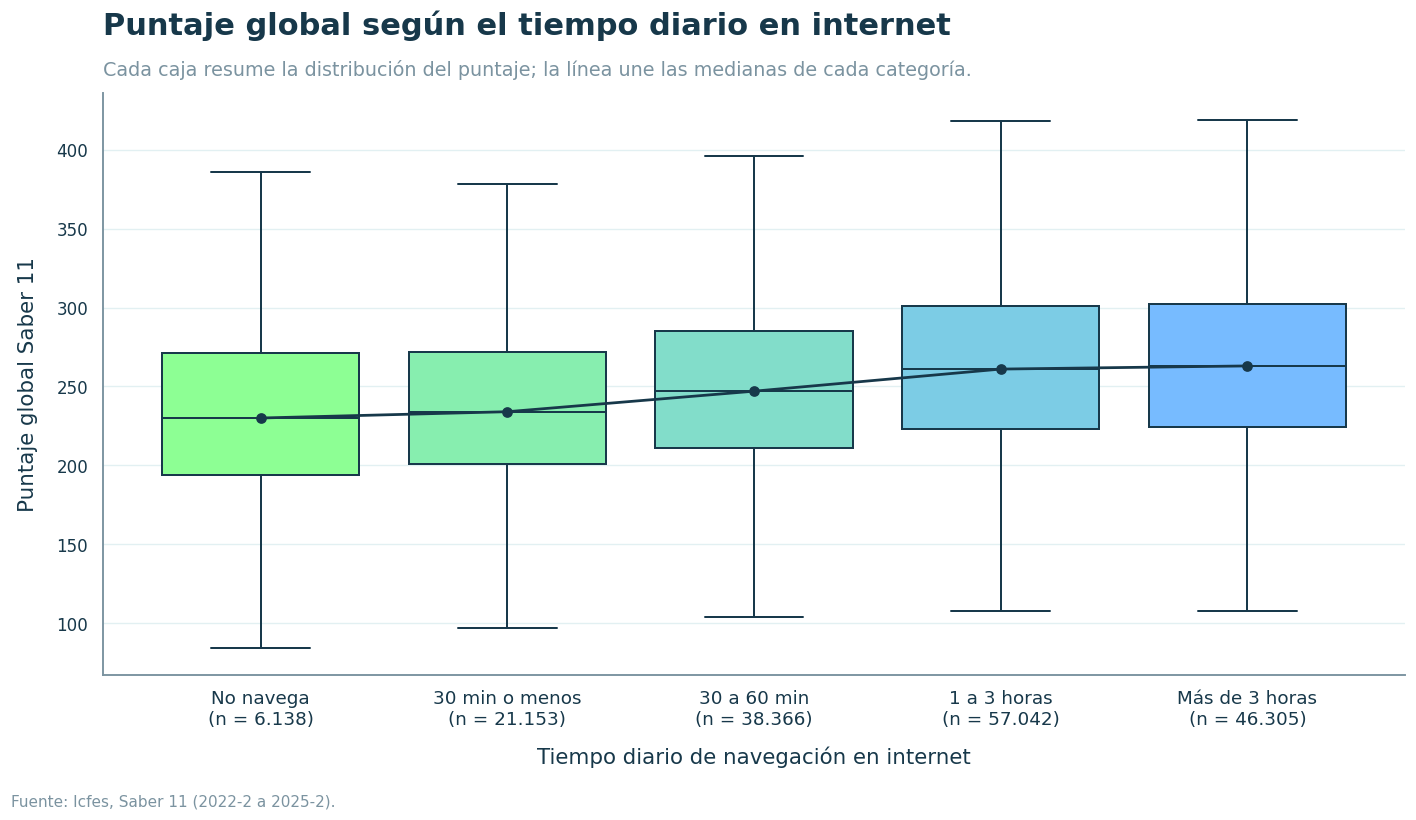

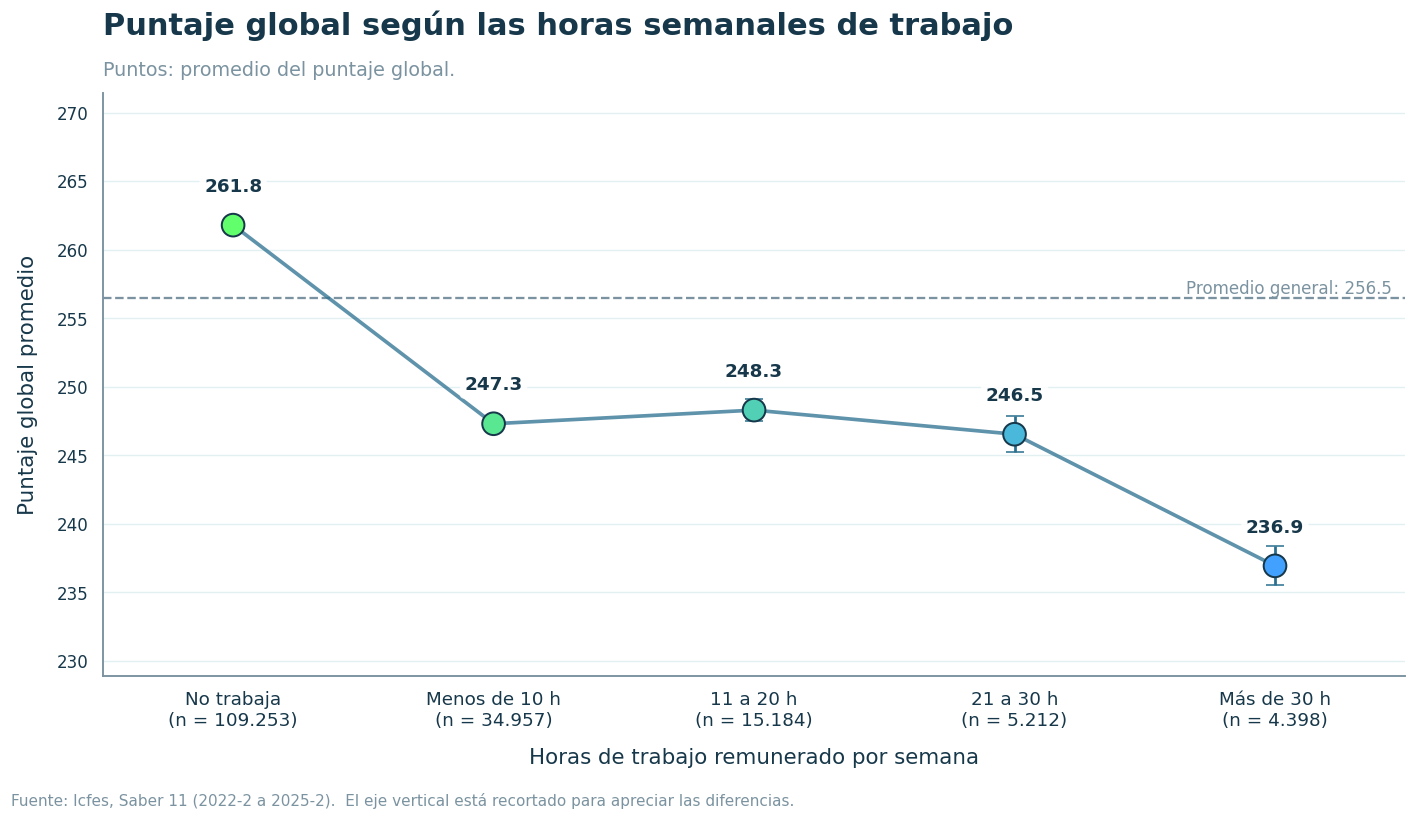

In [30]:
PALETA_G = ["#4fff5b", "#48ea7c", "#41d59d", "#3bc0bd", "#34abde", "#2d96ff"]
TXT_G = "#17384a"     # azul petróleo oscuro: títulos, ejes y contornos
TRAZO_G = "#2a6f8f"   # azul medio-oscuro: líneas y barras de error
GRS_G = "#7b93a0"     # subtítulos y notas
GRD_G = "#e2f0f2"     # rejilla suave

fuente = "Fuente: Icfes, Saber 11 (2022-2 a 2025-2). "

cmap_g = LinearSegmentedColormap.from_list("verde_azul", PALETA_G)

def colores_g(n, suavizar=0.0):
    """n colores equidistantes de la gama; 'suavizar' los mezcla con blanco (tono pastel)."""
    lista = []
    for v in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_g(v)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT_G,
    "axes.labelcolor": TXT_G,
    "axes.edgecolor": GRS_G,
    "xtick.color": TXT_G,
    "ytick.color": TXT_G,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD_G,
    "grid.linewidth": 0.9,
})

def titulo_g(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS_G)

orden_lectura = ["noleoporentretenimiento", "30minutosomenos", "entre30y60minutos",
                 "entre1y2horas", "masde2horas"]
etiquetas_lectura = {
    "noleoporentretenimiento": "No lee por entretenimiento",
    "30minutosomenos": "30 min o menos",
    "entre30y60minutos": "30 a 60 min",
    "entre1y2horas": "1 a 2 horas",
    "masde2horas": "Más de 2 horas",
}

orden_internet = ["nonavegainternet", "30minutosomenos", "entre30y60minutos",
                  "entre1y3horas", "masde3horas"]
etiquetas_internet = {
    "nonavegainternet": "No navega",
    "30minutosomenos": "30 min o menos",
    "entre30y60minutos": "30 a 60 min",
    "entre1y3horas": "1 a 3 horas",
    "masde3horas": "Más de 3 horas",
}

orden_trabajo = ["0", "menosde10horas", "entre11y20horas", "entre21y30horas", "masde30horas"]
etiquetas_trabajo = {
    "0": "No trabaja",
    "menosde10horas": "Menos de 10 h",
    "entre11y20horas": "11 a 20 h",
    "entre21y30horas": "21 a 30 h",
    "masde30horas": "Más de 30 h",
}

def resumen_habito(columna, orden, etiquetas):
    datos = df[[columna, objetivo]].dropna().copy()
    datos[columna] = datos[columna].astype(str)
    fuera_de_orden = sorted(set(datos[columna].unique()) - set(orden))
    if fuera_de_orden:
        print(f"Aviso ({columna}): categorías fuera del orden definido, excluidas del gráfico -> {fuera_de_orden}")
    datos = datos[datos[columna].isin(orden)].copy()
    datos["etiqueta"] = datos[columna].map(etiquetas)
    orden_etiquetas = [etiquetas[c] for c in orden if c in set(datos[columna])]
    resumen = (
        datos.groupby("etiqueta")[objetivo]
        .agg(estudiantes="size", promedio="mean", mediana="median", desviacion="std")
        .reindex(orden_etiquetas)
    )
    resumen["error"] = 1.96 * resumen["desviacion"] / np.sqrt(resumen["estudiantes"])
    return datos, resumen

lectura, resumen_lectura = resumen_habito("estu_dedicacionlecturadiaria", orden_lectura, etiquetas_lectura)
internet, resumen_internet = resumen_habito("estu_dedicacioninternet", orden_internet, etiquetas_internet)
trabajo, resumen_trabajo = resumen_habito("estu_horassemanatrabaja", orden_trabajo, etiquetas_trabajo)


def figura_cajas(datos, resumen, xlabel, principal, subtitulo, archivo):
    categorias = list(resumen.index)
    colores = dict(zip(categorias, colores_g(len(categorias), suavizar=0.35)))

    fig, ax = plt.subplots(figsize=(13, 7.5))
    sns.boxplot(data=datos, x="etiqueta", y=objetivo, hue="etiqueta",
                order=categorias, hue_order=categorias, palette=colores,
                showfliers=False, linewidth=1.3, linecolor=TXT_G, saturation=1,
                legend=False, ax=ax)
    # Línea que une las medianas: hace visible la tendencia entre categorías
    ax.plot(range(len(categorias)), resumen["mediana"].to_numpy(), color=TXT_G,
            marker="o", markersize=6, linewidth=1.8, zorder=5)

    ax.set_xticks(range(len(categorias)))
    ax.set_xticklabels([f"{c}\n(n = {miles(n)})" for c, n in zip(categorias, resumen["estudiantes"])],
                       fontsize=12)
    ax.set_xlabel(xlabel, fontsize=14, labelpad=12)
    ax.set_ylabel("Puntaje global Saber 11", fontsize=14, labelpad=12)
    ax.grid(axis="x", visible=False)
    titulo_g(ax, principal, subtitulo)
    fig.text(0.01, 0.01, fuente, fontsize=10, color=GRS_G)
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    # fig.savefig(archivo, dpi=300, bbox_inches="tight")
    plt.show()

figura_cajas(
    lectura, resumen_lectura,
    xlabel="Tiempo diario de lectura por entretenimiento",
    principal="Puntaje global según la lectura diaria por entretenimiento",
    subtitulo="Cada caja resume la distribución del puntaje; la línea une las medianas de cada categoría.",
    archivo="fig_habito_lectura.png",
)

figura_cajas(
    internet, resumen_internet,
    xlabel="Tiempo diario de navegación en internet",
    principal="Puntaje global según el tiempo diario en internet",
    subtitulo="Cada caja resume la distribución del puntaje; la línea une las medianas de cada categoría.",
    archivo="fig_habito_internet.png",
)

x = np.arange(len(resumen_trabajo))
y = resumen_trabajo["promedio"].to_numpy()
promedio_general = df[objetivo].mean()

fig_trabajo, ax = plt.subplots(figsize=(13, 7.5))
ax.axhline(promedio_general, color=GRS_G, linestyle="--", linewidth=1.5, zorder=1)
ax.text(len(x) - 0.55, promedio_general, f"Promedio general: {promedio_general:.1f}",
        ha="right", va="bottom", fontsize=11, color=GRS_G)
ax.plot(x, y, color=TRAZO_G, linewidth=2.4, alpha=0.75, zorder=3)
ax.errorbar(x, y, yerr=resumen_trabajo["error"], fmt="none", ecolor=TRAZO_G,
            elinewidth=1.8, capsize=6, zorder=4)
ax.scatter(x, y, s=220, c=colores_g(len(x), suavizar=0.10),
           edgecolors=TXT_G, linewidths=1.3, zorder=5)
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points", xytext=(0, 22),
                ha="center", fontsize=12, fontweight="bold", color=TXT_G, zorder=6,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85))

ax.set_xticks(x)
ax.set_xticklabels([f"{e}\n(n = {miles(n)})" for e, n in zip(resumen_trabajo.index, resumen_trabajo["estudiantes"])],
                   fontsize=12)
ax.set_xlim(-0.5, len(x) - 0.5)
lo = min((resumen_trabajo["promedio"] - resumen_trabajo["error"]).min(), promedio_general)
hi = max((resumen_trabajo["promedio"] + resumen_trabajo["error"]).max(), promedio_general)
margen = max(hi - lo, 1) * 0.25
ax.set_ylim(lo - margen, hi + margen * 1.4)
ax.set_xlabel("Horas de trabajo remunerado por semana", fontsize=14, labelpad=12)
ax.set_ylabel("Puntaje global promedio", fontsize=14, labelpad=12)
ax.grid(axis="x", visible=False)

titulo_g(ax, "Puntaje global según las horas semanales de trabajo",
         "Puntos: promedio del puntaje global.")
fig_trabajo.text(0.01, 0.01, fuente + " El eje vertical está recortado para apreciar las diferencias.",
                 fontsize=10, color=GRS_G)
fig_trabajo.tight_layout(rect=[0, 0.03, 1, 1])

plt.show()

En la primera grafica Se observa una asociación positiva entre el tiempo dedicado a la lectura por entretenimiento y el desempeño en Saber 11. A medida que aumenta el tiempo diario de lectura, la mediana del puntaje global también aumenta, pasando de aproximadamente 243 puntos entre quienes no leen por entretenimiento a cerca de 276 puntos entre quienes leen más de dos horas. Sin embargo, existe un amplio solapamiento entre las distribuciones, lo que indica que el hábito de lectura por sí solo no explica completamente las diferencias individuales en el desempeño.

---

El uso diario de internet presenta una asociación positiva con el puntaje global, particularmente al comparar estudiantes con poco o ningún uso frente a quienes navegan durante una hora o más. La mediana aumenta progresivamente hasta la categoría de una a tres horas diarias, mientras que entre una a tres horas y más de tres horas la diferencia es reducida, lo que sugiere una estabilización de la asociación en los niveles altos de uso. pero en este campo se tiene que tener en cuenta que el uso de internet tambien puede depender de muchos factores como si tiene o no internet, posee un dispositivo para conectarse o que tanto acceso tiene para recursos tecnologicos para estudiar.

---

Los estudiantes que no trabajan presentan un puntaje global promedio superior al de quienes trabajan. Entre los estudiantes que sí trabajan, los resultados son relativamente similares hasta las 30 horas semanales, aunque se observa una reducción considerable entre quienes trabajan más de 30 horas ya que es el grupo que presenta el menor promedio del conjunto.

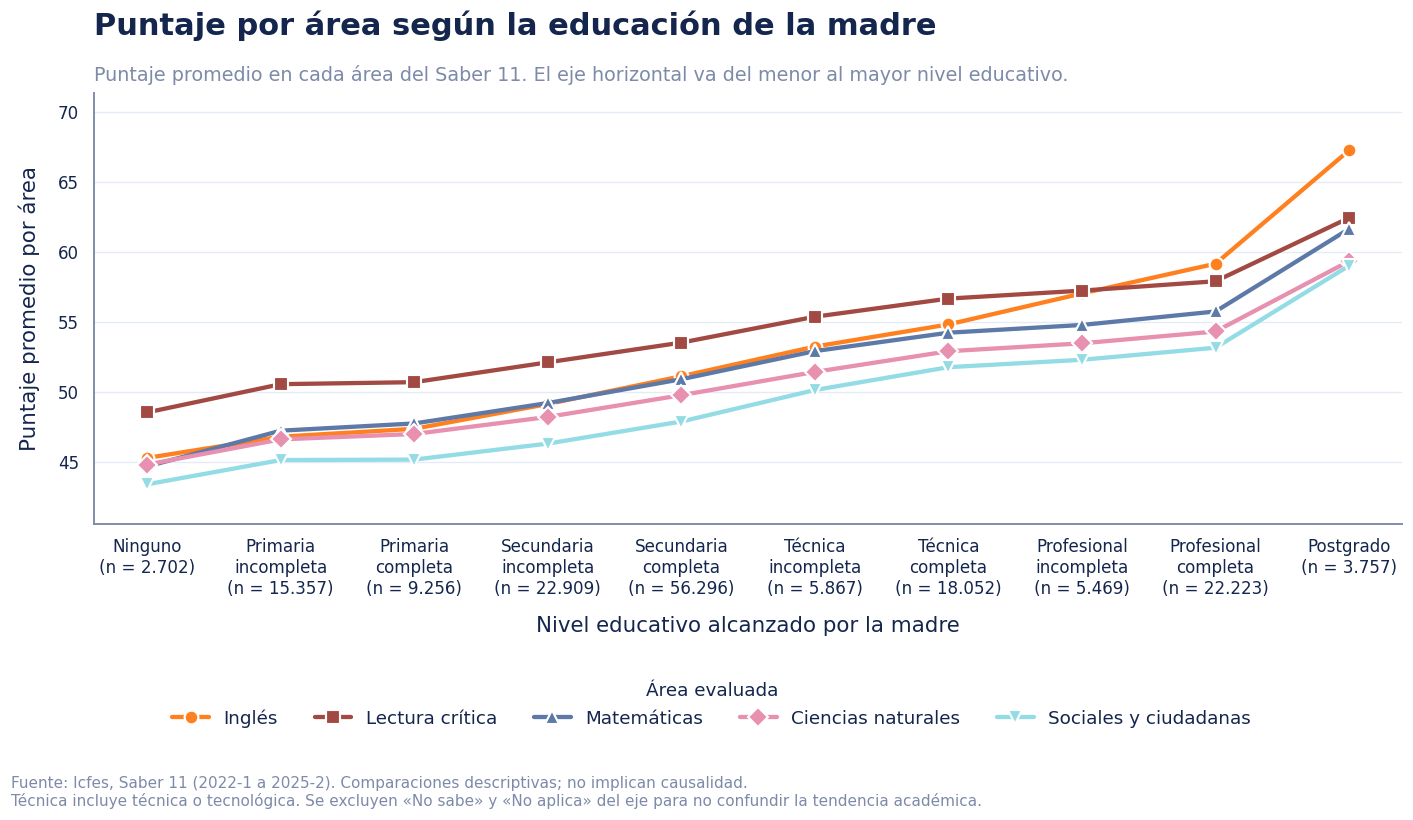

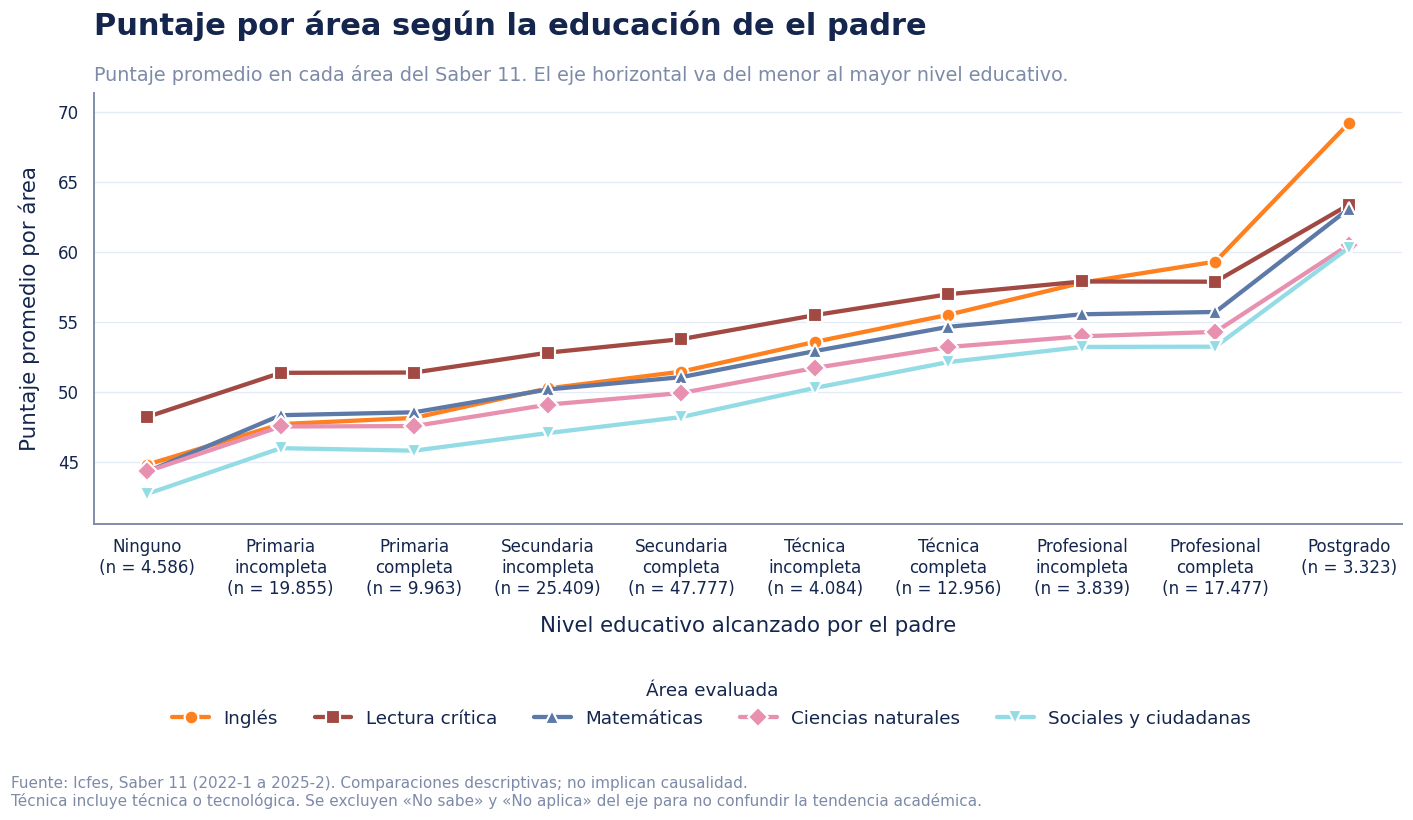

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb

PALETA_A = ["#FF6F00","#C71000", "#008EA0", "#8A4198", "#FF95A8", "#84D7E1"]
TXT_A = "#14264d"    # azul marino: títulos, ejes y contornos
GRS_A = "#7d8aa8"    # subtítulos y notas
GRD_A = "#e4ebf7"    # rejilla suave

fuente = ("Fuente: Icfes, Saber 11 (2022-1 a 2025-2). Comparaciones descriptivas; no implican causalidad.\n"
          "Técnica incluye técnica o tecnológica. Se excluyen «No sabe» y «No aplica» del eje "
          "para no confundir la tendencia académica.")

cmap_a = LinearSegmentedColormap.from_list("azul_cian", PALETA_A)

def colores_a(n, suavizar=0.0):
    """n colores equidistantes de la gama; 'suavizar' los mezcla con blanco (tono pastel)."""
    lista = []
    for v in np.linspace(0, 1, n):
        rgb = np.array(to_rgb(cmap_a(v)))
        lista.append(tuple(rgb + (1 - rgb) * suavizar))
    return lista

def miles(v):
    return f"{int(v):,}".replace(",", ".")

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "text.color": TXT_A,
    "axes.labelcolor": TXT_A,
    "axes.edgecolor": GRS_A,
    "xtick.color": TXT_A,
    "ytick.color": TXT_A,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRD_A,
    "grid.linewidth": 0.9,
})

def titulo_a(ax, principal, subtitulo):
    ax.set_title(principal, loc="left", fontsize=20, fontweight="bold", pad=38)
    ax.text(0, 1.03, subtitulo, transform=ax.transAxes, fontsize=12.5, color=GRS_A)

orden_educacion = [
    "ninguno", "primariaincompleta", "primariacompleta",
    "secundariabachilleratoincompleta", "secundariabachilleratocompleta",
    "tecnicaotecnologicaincompleta", "tecnicaotecnologicacompleta",
    "educacionprofesionalincompleta", "educacionprofesionalcompleta",
    "postgrado", "nosabe", "noaplica",
]

etiquetas_educacion = {
    "ninguno": "Ninguno",
    "primariaincompleta": "Primaria\nincompleta",
    "primariacompleta": "Primaria\ncompleta",
    "secundariabachilleratoincompleta": "Secundaria\nincompleta",
    "secundariabachilleratocompleta": "Secundaria\ncompleta",
    "tecnicaotecnologicaincompleta": "Técnica\nincompleta",
    "tecnicaotecnologicacompleta": "Técnica\ncompleta",
    "educacionprofesionalincompleta": "Profesional\nincompleta",
    "educacionprofesionalcompleta": "Profesional\ncompleta",
    "postgrado": "Postgrado",
    "nosabe": "No sabe",
    "noaplica": "No aplica",
}

nombres_areas = {
    "punt_ingles": "Inglés",
    "punt_lectura_critica": "Lectura crítica",
    "punt_matematicas": "Matemáticas",
    "punt_c_naturales": "Ciencias naturales",
    "punt_sociales_ciudadanas": "Sociales y ciudadanas",
}

niveles_academicos = orden_educacion[:10]
etiquetas_academicas = [etiquetas_educacion[nivel] for nivel in niveles_academicos]

def resumen_educacion(variable):
    base = df[[variable, *nombres_areas]].dropna(subset=[variable]).copy()
    base[variable] = base[variable].astype(str)
    sin_etiqueta = sorted(set(base[variable].unique()) - set(etiquetas_educacion))
    if sin_etiqueta:
        print(f"Aviso ({variable}): categorías sin etiqueta, excluidas del resumen -> {sin_etiqueta}")
    base["nivel_educativo"] = base[variable].map(etiquetas_educacion)
    orden_etiquetas = [etiquetas_educacion[nivel] for nivel in orden_educacion]

    grupos = base.groupby("nivel_educativo")[list(nombres_areas)]
    promedio = grupos.mean().reindex(orden_etiquetas).rename(columns=nombres_areas)
    cantidad = grupos.count().reindex(orden_etiquetas).rename(columns=nombres_areas)
    return promedio, cantidad

promedio_madre, n_madre = resumen_educacion("fami_educacionmadre")
promedio_padre, n_padre = resumen_educacion("fami_educacionpadre")

colores_areas = dict(zip(nombres_areas.values(), colores_a(len(nombres_areas), suavizar=0.12)))
marcadores_areas = dict(zip(nombres_areas.values(), ["o", "s", "^", "D", "v"]))

todos = pd.concat([promedio_madre.loc[etiquetas_academicas], promedio_padre.loc[etiquetas_academicas]])
y_min, y_max = todos.min().min(), todos.max().max()
margen = (y_max - y_min) * 0.08

def figura_educacion(promedio, cantidad, progenitor, archivo):
    n_por_nivel = cantidad.loc[etiquetas_academicas].max(axis=1)
    x = np.arange(len(etiquetas_academicas))

    fig, ax = plt.subplots(figsize=(13, 7.5))
    for area in nombres_areas.values():
        ax.plot(x, promedio.loc[etiquetas_academicas, area],
                color=colores_areas[area], marker=marcadores_areas[area],
                markersize=9, linewidth=2.8, markeredgecolor="white",
                markeredgewidth=1.4, label=area)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{e}\n(n = {miles(n)})" for e, n in zip(etiquetas_academicas, n_por_nivel)],
                       fontsize=11)
    ax.set_xlim(-0.4, len(x) - 0.6)
    ax.set_ylim(y_min - margen, y_max + margen)
    ax.set_xlabel(f"Nivel educativo alcanzado por {progenitor}", fontsize=14, labelpad=12)
    ax.set_ylabel("Puntaje promedio por área", fontsize=14, labelpad=12)
    ax.grid(axis="x", visible=False)

    titulo_a(ax, f"Puntaje por área según la educación de {progenitor}",
             "Puntaje promedio en cada área del Saber 11. El eje horizontal va del menor al mayor nivel educativo.")

    fig.legend(*ax.get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.5, 0.085),
               ncol=5, frameon=False, fontsize=12, title="Área evaluada", title_fontsize=12)
    fig.text(0.01, 0.01, fuente, fontsize=10, color=GRS_A)
    fig.tight_layout(rect=[0, 0.19, 1, 1])

    plt.show()

figura_educacion(promedio_madre, n_madre, "la madre", "fig_educacion_madre.png")
figura_educacion(promedio_padre, n_padre, "el padre", "fig_educacion_padre.png")



El nivel educativo de los padres presenta una asociación positiva y consistente con el desempeño de los estudiantes en todas las áreas evaluadas por el ICFES. Tanto para la educación de la madre como del padre, los puntajes promedio aumentan progresivamente a medida que se alcanzan mayores niveles educativos, siendo los estudiantes cuyos padres cuentan con formación profesional o de posgrado quienes presentan los mayores resultados.

La relación se observa en todas las asignaturas, lo que indica que no se limita a una competencia específica. Sin embargo, inglés presenta la mayor diferencia entre los extremos educativos, especialmente entre estudiantes cuyos padres no poseen educación formal y aquellos con estudios de posgrado.Este patrón podría reflejar no solamente condiciones económicas, sino también diferencias en capital educativo y cultural del hogar, disponibilidad de recursos académicos y oportunidades de aprendizaje.

In [33]:
print(sorted(df["fami_educacionmadre"].dropna().astype(str).unique()))
print(sorted(df["fami_educacionpadre"].dropna().astype(str).unique()))

['educacionprofesionalcompleta', 'educacionprofesionalincompleta', 'ninguno', 'noaplica', 'nosabe', 'postgrado', 'primariacompleta', 'primariaincompleta', 'secundariabachilleratocompleta', 'secundariabachilleratoincompleta', 'tecnicaotecnologicacompleta', 'tecnicaotecnologicaincompleta']
['educacionprofesionalcompleta', 'educacionprofesionalincompleta', 'ninguno', 'noaplica', 'nosabe', 'postgrado', 'primariacompleta', 'primariaincompleta', 'secundariabachilleratocompleta', 'secundariabachilleratoincompleta', 'tecnicaotecnologicacompleta', 'tecnicaotecnologicaincompleta']


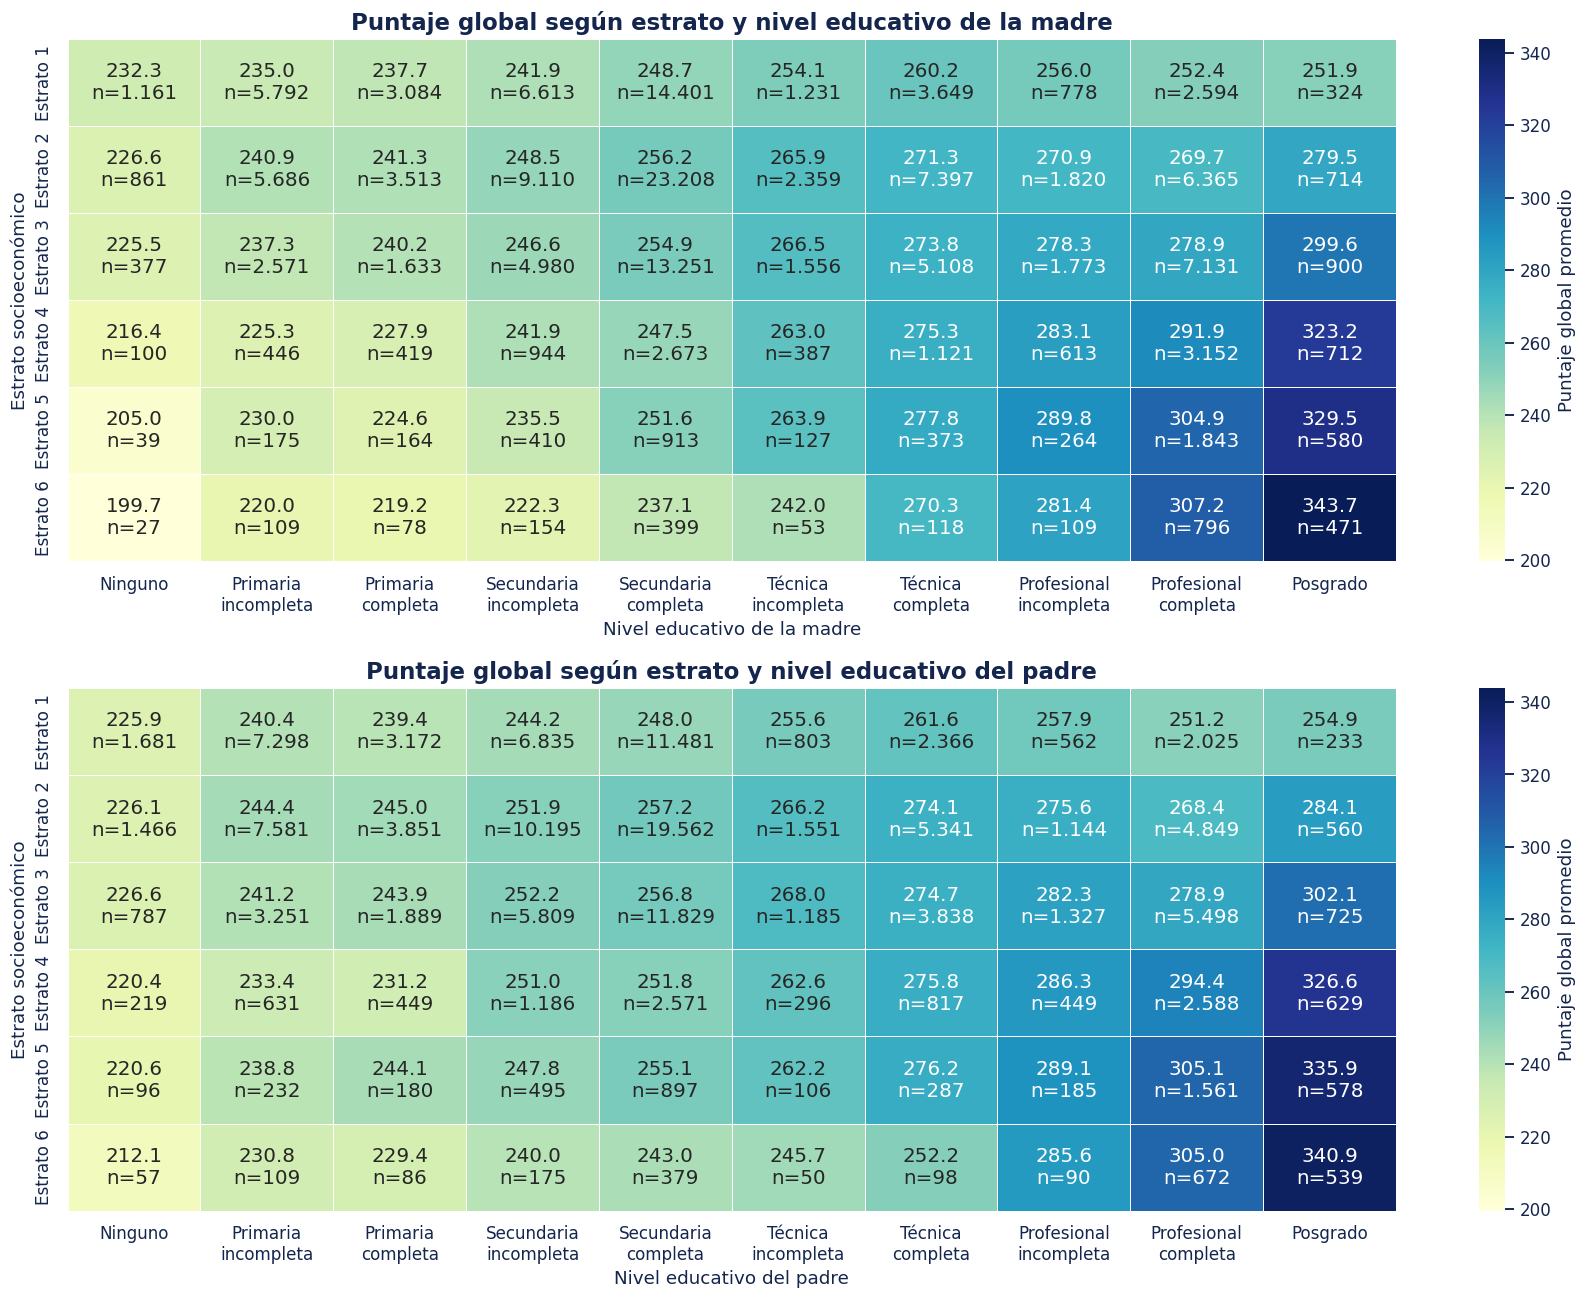

In [36]:
orden_estrato = [
    "estrato1",
    "estrato2",
    "estrato3",
    "estrato4",
    "estrato5",
    "estrato6"
]

orden_educacion = [
    "ninguno",
    "primariaincompleta",
    "primariacompleta",
    "secundariabachilleratoincompleta",
    "secundariabachilleratocompleta",
    "tecnicaotecnologicaincompleta",
    "tecnicaotecnologicacompleta",
    "educacionprofesionalincompleta",
    "educacionprofesionalcompleta",
    "postgrado"
]


etiquetas_estrato = {
    "estrato1": "Estrato 1",
    "estrato2": "Estrato 2",
    "estrato3": "Estrato 3",
    "estrato4": "Estrato 4",
    "estrato5": "Estrato 5",
    "estrato6": "Estrato 6"
}


etiquetas_educacion = {
    "ninguno": "Ninguno",
    "primariaincompleta": "Primaria\nincompleta",
    "primariacompleta": "Primaria\ncompleta",
    "secundariabachilleratoincompleta": "Secundaria\nincompleta",
    "secundariabachilleratocompleta": "Secundaria\ncompleta",
    "tecnicaotecnologicaincompleta": "Técnica\nincompleta",
    "tecnicaotecnologicacompleta": "Técnica\ncompleta",
    "educacionprofesionalincompleta": "Profesional\nincompleta",
    "educacionprofesionalcompleta": "Profesional\ncompleta",
    "postgrado": "Posgrado"
}


def preparar_heatmap(df, columna_educacion):

    datos = df[
        [
            "fami_estratovivienda",
            columna_educacion,
            "punt_global"
        ]
    ].dropna().copy()

    datos = datos[
        datos["fami_estratovivienda"].isin(orden_estrato)
        &
        datos[columna_educacion].isin(orden_educacion)
    ]


    tabla_promedio = (
        datos.pivot_table(
            values="punt_global",
            index="fami_estratovivienda",
            columns=columna_educacion,
            aggfunc="mean",
            observed=True
        )
        .reindex(
            index=orden_estrato,
            columns=orden_educacion
        )
    )

    tabla_n = (
        datos.pivot_table(
            values="punt_global",
            index="fami_estratovivienda",
            columns=columna_educacion,
            aggfunc="count",
            observed=True
        )
        .reindex(
            index=orden_estrato,
            columns=orden_educacion
        )
    )

    return tabla_promedio, tabla_n

tabla_madre, n_madre = preparar_heatmap(
    df,
    "fami_educacionmadre"
)

tabla_padre, n_padre = preparar_heatmap(
    df,
    "fami_educacionpadre"
)

vmin = min(
    tabla_madre.min().min(),
    tabla_padre.min().min()
)

vmax = max(
    tabla_madre.max().max(),
    tabla_padre.max().max()
)

def crear_anotaciones(tabla_promedio, tabla_n):

    anotaciones = tabla_promedio.copy().astype(object)

    for fila in tabla_promedio.index:
        for columna in tabla_promedio.columns:

            promedio = tabla_promedio.loc[fila, columna]
            n = tabla_n.loc[fila, columna]

            if pd.notna(promedio) and pd.notna(n):

                anotaciones.loc[fila, columna] = (
                    f"{promedio:.1f}\n"
                    f"n={int(n):,}".replace(",", ".")
                )

            else:
                anotaciones.loc[fila, columna] = ""

    return anotaciones


annot_madre = crear_anotaciones(
    tabla_madre,
    n_madre
)

annot_padre = crear_anotaciones(
    tabla_padre,
    n_padre
)

def renombrar_tabla(tabla):

    tabla = tabla.copy()

    tabla.index = [
        etiquetas_estrato[x]
        for x in tabla.index
    ]

    tabla.columns = [
        etiquetas_educacion[x]
        for x in tabla.columns
    ]

    return tabla


tabla_madre_viz = renombrar_tabla(tabla_madre)
tabla_padre_viz = renombrar_tabla(tabla_padre)

annot_madre.index = tabla_madre_viz.index
annot_madre.columns = tabla_madre_viz.columns

annot_padre.index = tabla_padre_viz.index
annot_padre.columns = tabla_padre_viz.columns


fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 12)
)


sns.heatmap(
    tabla_madre_viz,
    annot=annot_madre,
    fmt="",
    cmap="YlGnBu",
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Puntaje global promedio"
    },
    ax=axes[0]
)

axes[0].set_title(
    "Puntaje global según estrato y nivel educativo de la madre",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Nivel educativo de la madre"
)

axes[0].set_ylabel(
    "Estrato socioeconómico"
)

sns.heatmap(
    tabla_padre_viz,
    annot=annot_padre,
    fmt="",
    cmap="YlGnBu",
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Puntaje global promedio"
    },
    ax=axes[1]
)

axes[1].set_title(
    "Puntaje global según estrato y nivel educativo del padre",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Nivel educativo del padre"
)

axes[1].set_ylabel(
    "Estrato socioeconómico"
)


plt.tight_layout()

plt.show()

El análisis conjunto del estrato socioeconómico y el nivel educativo de los padres evidencia que ambas características están relacionadas con el desempeño en Saber 11, aunque el nivel educativo parental presenta un patrón particularmente consistente. Dentro de un mismo estrato, el puntaje global tiende a incrementarse conforme aumenta la formación académica de la madre o del padre, observándose las mayores diferencias en los niveles técnico, profesional y de posgrado.
Este comportamiento sugiere que la educación parental puede aportar una dimensión diferente al nivel económico, posiblemente relacionada con el capital educativo y cultural del hogar. Por su parte, la relación entre estrato y desempeño no se mantiene con la misma intensidad en todos los niveles educativos, lo que evidencia una posible interacción entre ambas variables.
Las combinaciones extremas deben interpretarse con cuidado, ya que algunas presentan tamaños muestrales reducidos.

In [23]:
promedio_municipio = (
    df.groupby("estu_mcpio_reside", as_index=False)["punt_global"]
    .mean()
)

promedio_municipio.columns = ["municipio", "promedio_punt_global"]


promedio_municipio["municipio"] = (
    promedio_municipio["municipio"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)


top_5_mejores = promedio_municipio.sort_values(
    by="promedio_punt_global",
    ascending=False
).head(5)

top_5_mejores["grupo"] = "Mejor promedio"


top_5_peores = promedio_municipio.sort_values(
    by="promedio_punt_global",
    ascending=True
).head(5)

top_5_peores["grupo"] = "Peor promedio"


top_municipios = pd.concat(
    [top_5_mejores, top_5_peores],
    ignore_index=True
)


fig = px.bar(
    top_municipios,
    x="promedio_punt_global",
    y="municipio",
    orientation="h",
    facet_col="grupo",
    text=top_municipios["promedio_punt_global"].round(1),
    color="municipio",
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title="Top 5 mejores y peores municipios según promedio de puntaje global"
)

fig.update_traces(
    textposition="outside",
    marker_line_width=1.2,
    marker_line_color="rgba(0,0,0,0.25)"
)

fig.update_layout(
    font=dict(
        family="DejaVu Serif",
        size=13
    ),
    title=dict(
        text="Top 5 mejores y peores municipios según promedio de puntaje global",
        font=dict(
            family="DejaVu Serif",
            size=20
        ),
        x=0.5
    ),
    xaxis_title="Promedio puntaje global",
    yaxis_title="Municipio de residencia",
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    height=500,
    width=1100,
    margin=dict(l=180, r=80, t=90, b=60)
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="lightgray",
    matches=None
)

fig.update_yaxes(
    autorange="reversed",
    automargin=True
)

fig.for_each_annotation(
    lambda a: a.update(
        text=a.text.split("=")[-1],
        font=dict(
            family="DejaVu Serif",
            size=15
        )
    )
)

fig.show()

En el gráfico se observan los cinco municipios con mayores y menores puntajes globales promedio de Saber 11 durante el periodo analizado. Guadalajara de Buga y Palmira se ubican entre los municipios con mejores resultados promedio, mientras que Buenaventura y Argelia aparecen entre los de menor desempeño. Esto evidencia diferencias territoriales en los resultados académicos. Sin embargo, el promedio municipal resume el comportamiento general y no refleja la variabilidad interna: dentro de un mismo municipio pueden existir estudiantes con resultados considerablemente superiores o inferiores al promedio. Por esta razón, estas diferencias no deben interpretarse como un efecto directo del municipio, ya que pueden estar relacionadas con factores socioeconómicos, familiares e institucionales que varían entre territorios.

In [24]:
paleta_estratos = [
    "#90CAF9",
    "#64B5F6",
    "#42A5F5",
    "#1E88E5",
    "#1976D2",
    "#1565C0",
    "#0D47A1"
]

promedio_estrato = (
    df.groupby("fami_estratovivienda", as_index=False)["punt_global"]
    .mean()
)

promedio_estrato.columns = [
    "estrato_vivienda",
    "promedio_punt_global"
]

promedio_estrato = promedio_estrato.sort_values(
    by="promedio_punt_global",
    ascending=False
)

promedio_estrato["estrato_vivienda"] = (
    promedio_estrato["estrato_vivienda"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)

fig = px.bar(
    promedio_estrato,
    x="estrato_vivienda",
    y="promedio_punt_global",
    text=promedio_estrato["promedio_punt_global"].round(1),
    color="estrato_vivienda",
    color_discrete_sequence=paleta_estratos,
    title="Puntaje global promedio por estrato"
)

fig.update_traces(
    textposition="outside",
    marker_line_width=1,
    marker_line_color="rgba(0,0,0,0.15)"
)

fig.update_layout(
    font=dict(
        family="DejaVu Serif",
        size=14,
        color="#1B263B"
    ),

    title=dict(
        text="Puntaje global promedio por estrato",
        font=dict(
            family="DejaVu Serif",
            size=22
        ),
        x=0.5
    ),

    xaxis_title="Estrato de vivienda",
    yaxis_title="Promedio puntaje global",

    plot_bgcolor="white",
    paper_bgcolor="white",

    showlegend=False,

    height=500,
    width=850,

    margin=dict(
        l=70,
        r=40,
        t=60,
        b=70
    )
)

fig.update_xaxes(
    showgrid=False,
    tickfont=dict(size=13)
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="rgba(200,200,200,0.35)"
)

fig.show()

El estrato socioeconómico presenta una asociación positiva y bastante consistente con el puntaje global. A medida que aumenta el estrato, también aumenta el promedio del Saber 11, pasando de aproximadamente 245,9 puntos en estrato 1 a 283 puntos en estrato 6. Esto representa una diferencia cercana a 37 puntos entre los extremos. El grupo sin estrato presenta el promedio más bajo, con alrededor de 228 puntos. Estos resultados sugieren una relación importante entre las condiciones socioeconómicas del hogar y el desempeño académico.

In [25]:
df_jornada = df[["cole_jornada", "punt_global"]].copy()


orden_jornada = (
    df_jornada
    .groupby("cole_jornada")["punt_global"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Paleta
paleta_jornada = [
    "#EA698B",
    "#D55D92",
    "#C05299",
    "#AC46A1",
    "#973AA8",
    "#822FAF",
]

fig = go.Figure()

for jornada, color in zip(orden_jornada, paleta_jornada):
    datos = df_jornada.loc[
        df_jornada["cole_jornada"] == jornada,
        "punt_global"
    ]

    fig.add_trace(
        go.Box(
            y=datos,
            name=str(jornada),
            fillcolor=color,
            marker_color=color,
            line=dict(color="rgba(0,0,0,0.45)", width=1.2),
            boxmean=True
        )
    )

fig.update_layout(
    title=dict(
        text="Distribución del puntaje global según jornada del colegio",
        font=dict(
            family="DejaVu Serif",
            size=20
        ),
        x=0.5
    ),
    font=dict(
        family="DejaVu Serif",
        size=13
    ),
    xaxis_title="Jornada del colegio",
    yaxis_title="Puntaje global",
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    height=550,
    width=1000,
    margin=dict(l=80, r=80, t=90, b=80)
)

fig.update_xaxes(
    showgrid=False
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray"
)

fig.show()

El boxplot muestra diferencias claras en la distribución del puntaje global según la jornada escolar. La jornada completa presenta la mediana más alta, cercana a los 300 puntos, mientras que las jornadas nocturna y sabatina presentan las medianas más bajas, alrededor de 200–210 puntos. Las jornadas de mañana y única muestran comportamientos muy similares, tanto en la mediana como en la dispersión, mientras que la jornada de tarde se ubica en un nivel intermedio.
Aunque existen diferencias entre las medianas, las distribuciones presentan un amplio solapamiento, lo que indica que la jornada escolar no determina por sí sola el desempeño individual. Además, en todas las jornadas se observan valores atípicos tanto altos como bajos, evidenciando estudiantes con resultados alejados del comportamiento central de cada grupo. Se tiene que tener en cuenta ademas que la jornada completa tiende a relacionarse con la jornada que toman los colegios no oficiales.